In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULT_DIR = Path("../results/data_quality")

df = pd.read_parquet(
    RESULT_DIR / "eda_sample.parquet"
)

class_dist = pd.read_csv(
    RESULT_DIR / "class_distribution.csv"
)

print("EDA sample shape:", df.shape)
print(df["Label"].value_counts())

EDA sample shape: (300000, 81)
Label
Benign                      252602
DDoS attacks-LOIC-HTTP       11559
DoS attacks-Hulk              9202
DDOS attack-HOIC              7524
Bot                           5678
FTP-BruteForce                3866
SSH-Bruteforce                3759
DoS attacks-SlowHTTPTest      2868
Infilteration                 1804
DoS attacks-GoldenEye          870
DoS attacks-Slowloris          206
DDOS attack-LOIC-UDP            38
Brute Force -Web                16
Brute Force -XSS                 5
SQL Injection                    3
Name: count, dtype: int64


In [2]:
class_dist

,Label,count,percentage,ratio_to_majority
0,Benign,13484708,83.070014,1.000000
1,DDOS attack-HOIC,686012,4.226048,0.050873
2,DDoS attacks-LOIC-HTTP,576191,3.549517,0.042729
3,DoS attacks-Hulk,461912,2.845522,0.034255
4,Bot,286191,1.763026,0.021223
5,FTP-BruteForce,193360,1.191158,0.014339
6,SSH-Bruteforce,187589,1.155607,0.013911
7,Infilteration,161934,0.997564,0.012009
8,DoS attacks-SlowHTTPTest,139890,0.861766,0.010374
9,DoS attacks-GoldenEye,41508,0.255702,0.003078


In [3]:
print(class_dist.columns.tolist())

['Label', 'count', 'percentage', 'ratio_to_majority']


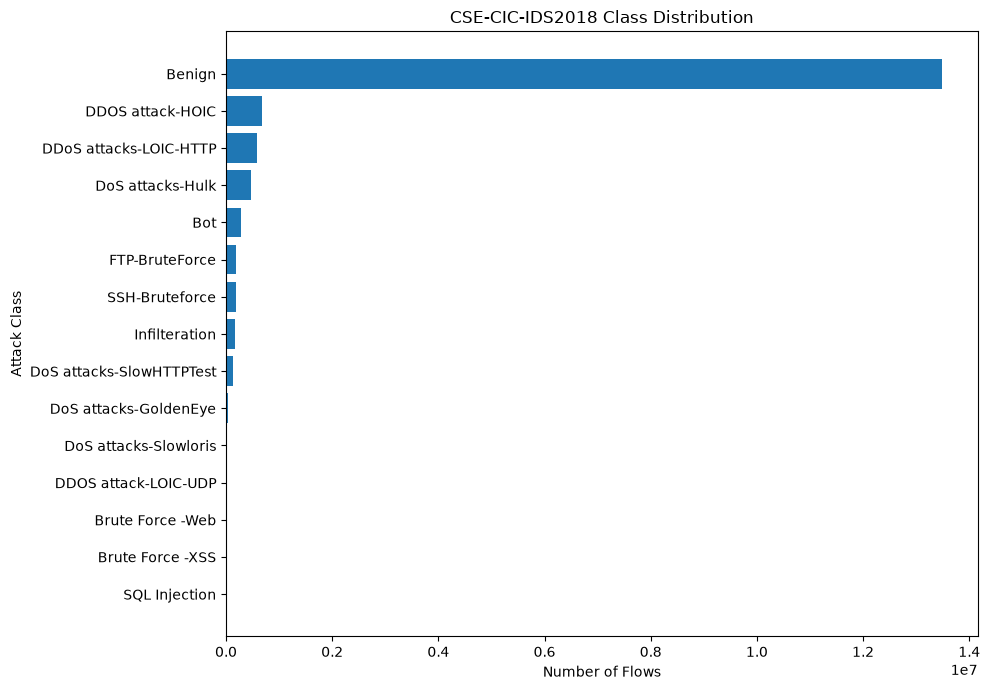

In [4]:
plot_df = (
    class_dist
    .sort_values("count", ascending=True)
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["Label"],
    plot_df["count"]
)

plt.xlabel("Number of Flows")
plt.ylabel("Attack Class")
plt.title("CSE-CIC-IDS2018 Class Distribution")

plt.tight_layout()
plt.show()

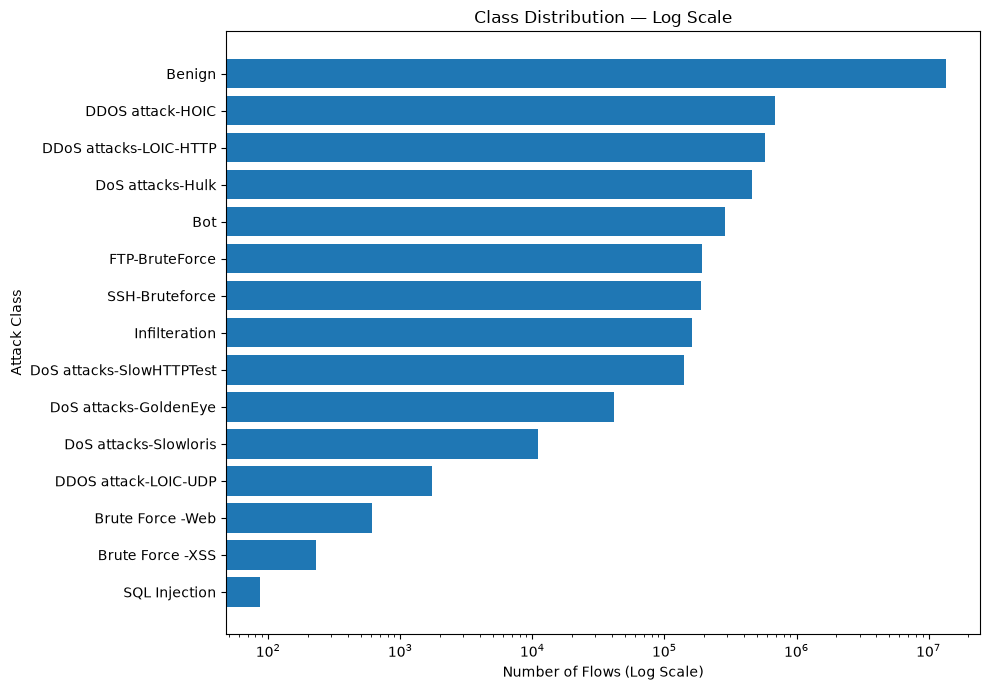

In [5]:
plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["Label"],
    plot_df["count"]
)

plt.xscale("log")

plt.xlabel("Number of Flows (Log Scale)")
plt.ylabel("Attack Class")
plt.title("Class Distribution — Log Scale")

plt.tight_layout()
plt.show()

In [7]:
traffic_features = [
    "Flow Duration",
    "Tot Fwd Pkts",
    "Tot Bwd Pkts",
    "TotLen Fwd Pkts",
    "TotLen Bwd Pkts",
    "Flow Byts/s",
    "Flow Pkts/s",
]

In [8]:
traffic_summary = (
    df.groupby("Label")[traffic_features]
      .median()
      .round(2)
)

traffic_summary

,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Flow Byts/s,Flow Pkts/s
Label,,,,,,,
Benign,43042.5,2.0,1.0,51.0,120.0,1086.27,87.36
Bot,8991.0,3.0,2.0,0.0,129.0,6390.44,797.58
Brute Force -Web,5008202.0,4.5,1.5,646.0,182.0,117.59,1.60
Brute Force -XSS,5284445.0,4.0,4.0,365.0,809.0,222.16,5.34
DDOS attack-HOIC,10557.0,2.0,0.0,0.0,0.0,0.00,411.03
DDOS attack-LOIC-UDP,119713224.0,115036.0,0.0,3681152.0,0.0,30740.05,960.63
DDoS attacks-LOIC-HTTP,1746892.0,3.0,4.0,20.0,964.0,516.88,3.81
DoS attacks-GoldenEye,6865980.5,4.0,3.0,353.5,662.0,121.40,1.03
DoS attacks-Hulk,13420.5,2.0,0.0,0.0,0.0,0.00,166.29


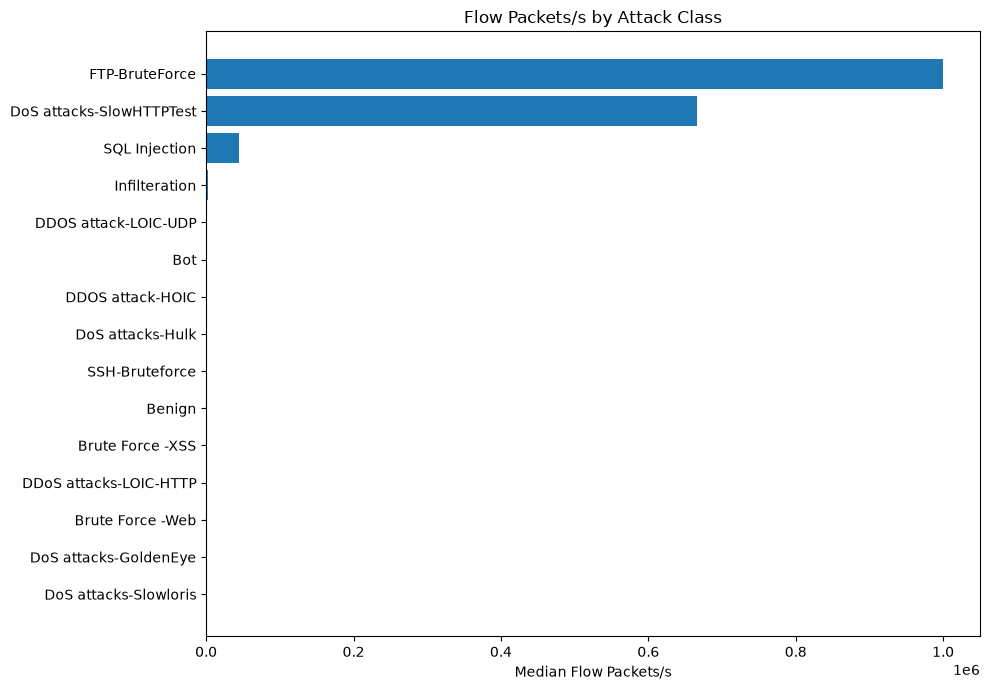

In [9]:
feature = "Flow Pkts/s"

plot_data = []

for label, group in df.groupby("Label"):
    values = group[feature].replace([np.inf, -np.inf], np.nan).dropna()

    if len(values):
        plot_data.append(
            {
                "Label": label,
                "Median": values.median()
            }
        )

plot_data = pd.DataFrame(plot_data).sort_values("Median")

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data["Label"],
    plot_data["Median"]
)

plt.xlabel("Median Flow Packets/s")
plt.title("Flow Packets/s by Attack Class")

plt.tight_layout()
plt.show()

In [10]:
df["Traffic Type"] = np.where(
    df["Label"].str.lower().eq("benign"),
    "Benign",
    "Attack"
)

In [11]:
binary_summary = (
    df.groupby("Traffic Type")[traffic_features]
      .median()
      .T
)

binary_summary

Traffic Type,Attack,Benign
Flow Duration,12183.500000,43042.500000
Tot Fwd Pkts,2.000000,2.000000
Tot Bwd Pkts,1.000000,1.000000
TotLen Fwd Pkts,0.000000,51.000000
TotLen Bwd Pkts,0.000000,120.000000
Flow Byts/s,0.000000,1086.269616
Flow Pkts/s,281.849798,87.357226


Sample: ../results/data_quality/eda_sample.parquet
Output: ../results/network_eda

[EDA Sample]
Rows   : 300000
Columns: 81

[Columns]
['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', '

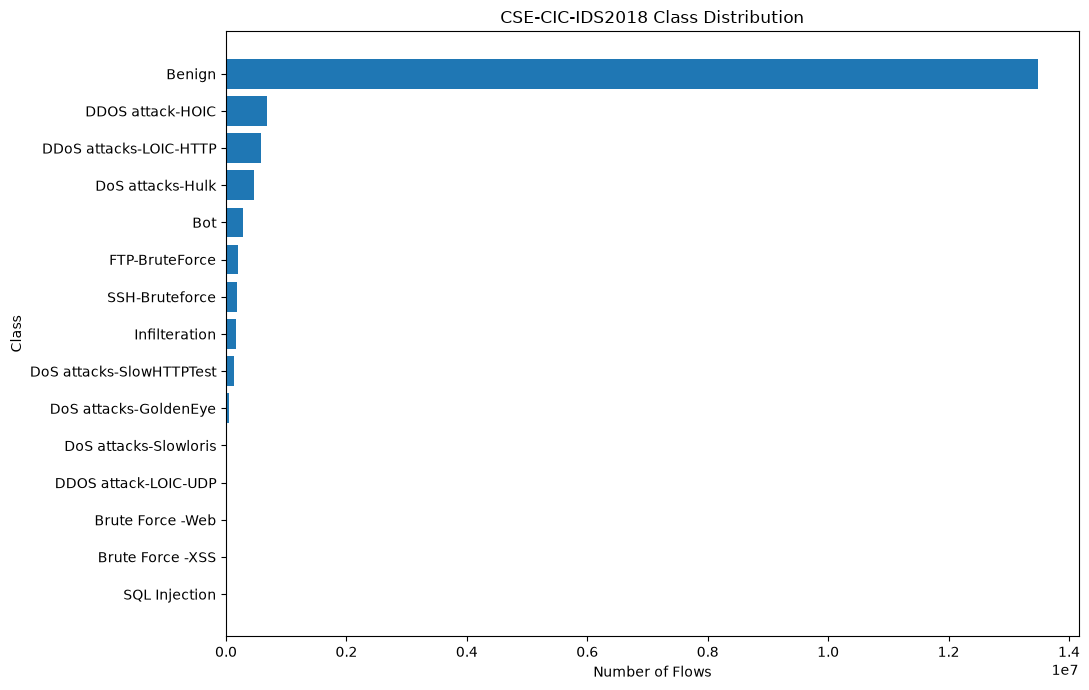

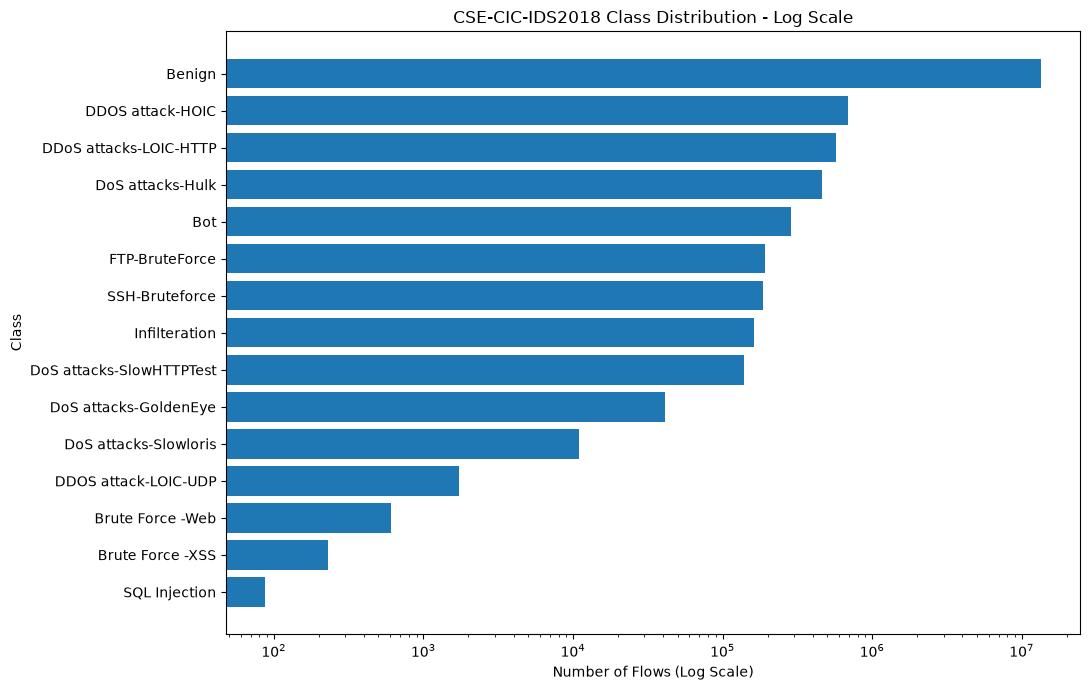


2. SOURCE FILE × LABEL
Label                                               Benign   Bot  \
source_file                                                        
Friday-02-03-2018_TrafficForML_CICFlowMeter.csv      15266  5678   
Friday-16-02-2018_TrafficForML_CICFlowMeter.csv       8924     0   
Friday-23-02-2018_TrafficForML_CICFlowMeter.csv      20939     0   
Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv   147440     0   
Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv     4827     0   
Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv    19860     0   
Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv    20974     0   
Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv   13348     0   
Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv    1024     0   

Label                                               Brute Force -Web  \
source_file                                                            
Friday-02-03-2018_TrafficForML_CICFlowMeter.csv                    0   
Friday-16-0

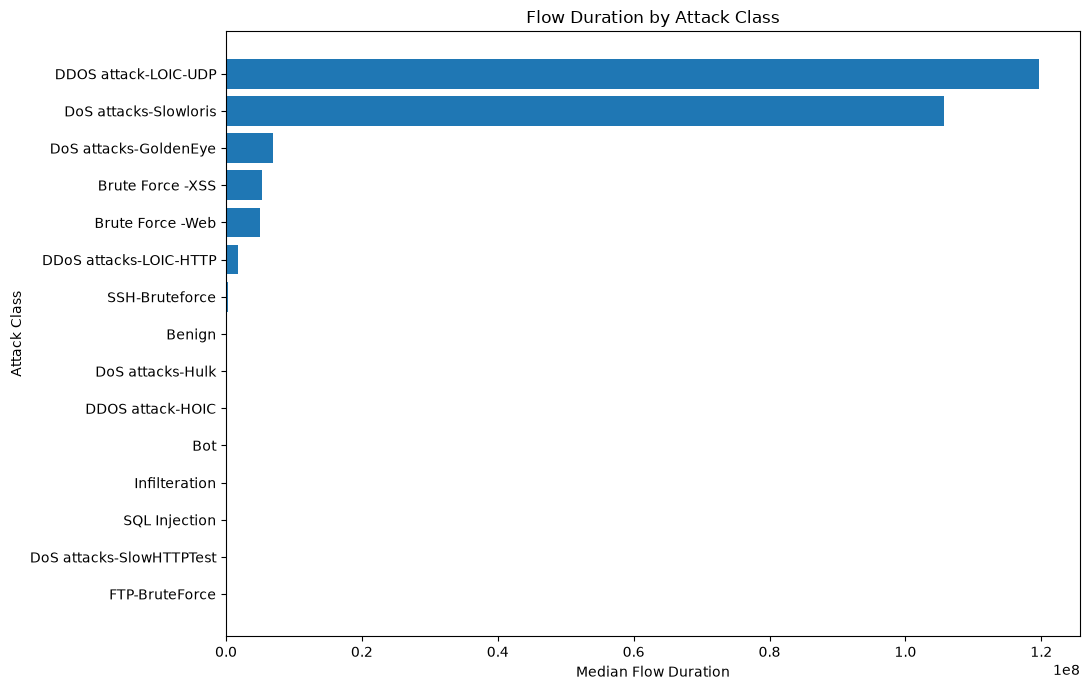

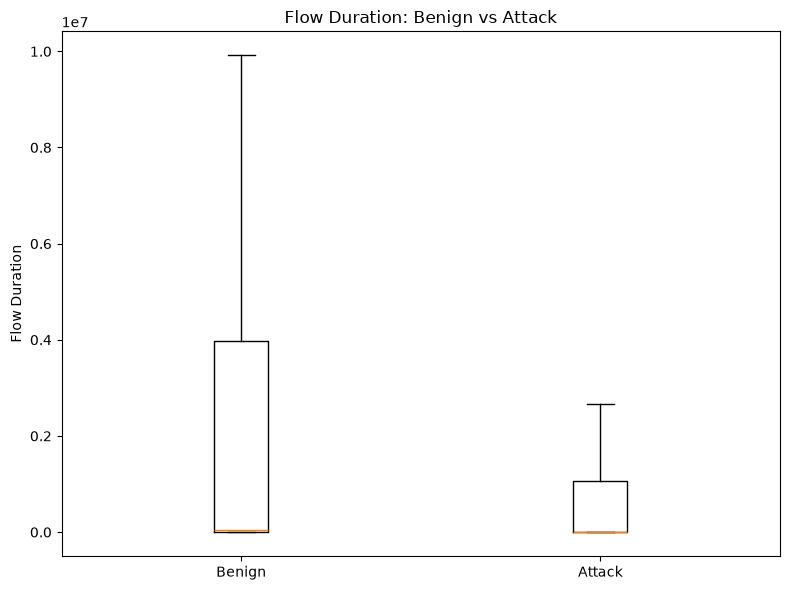

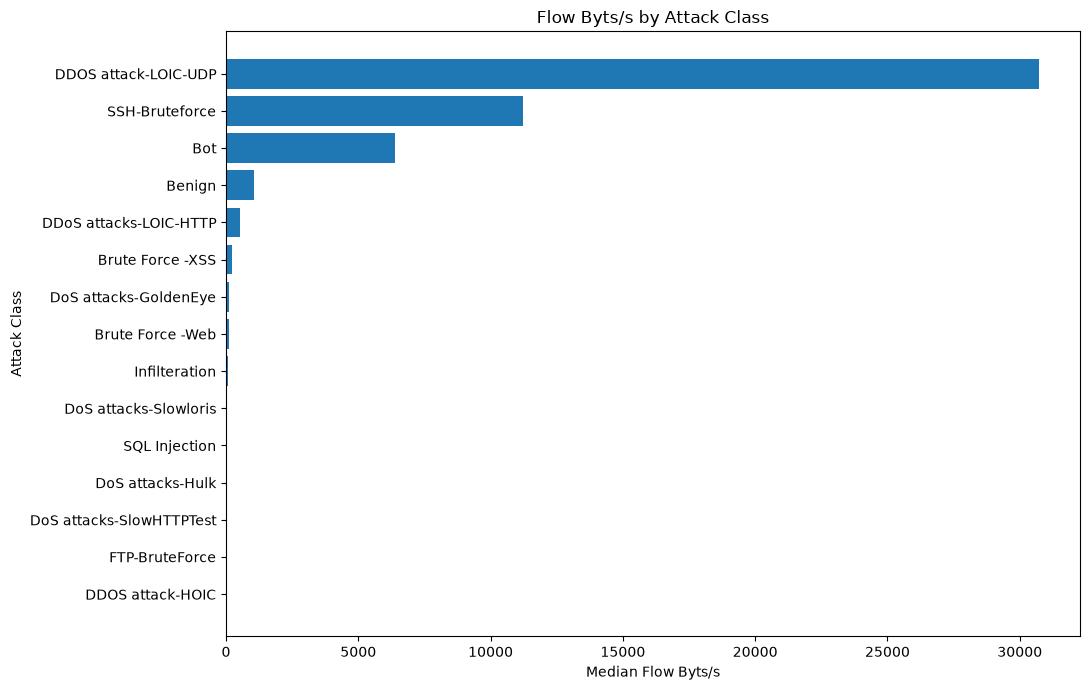

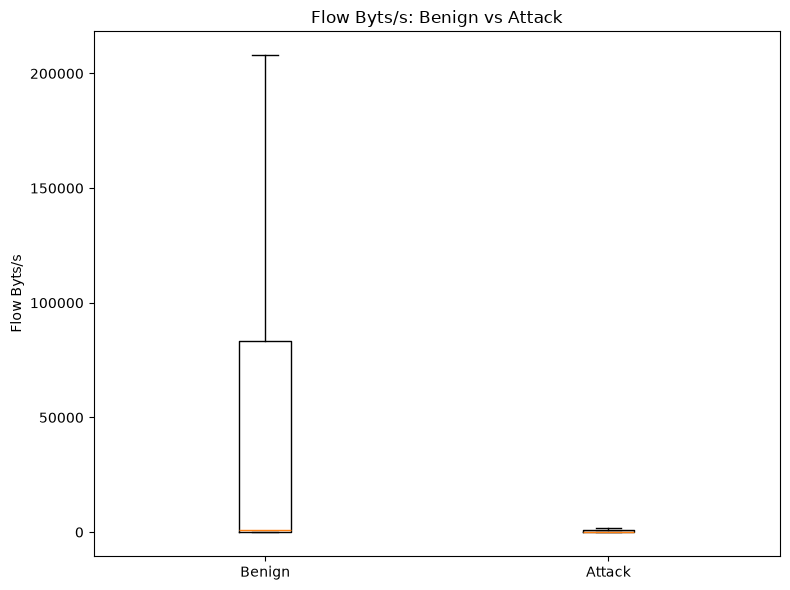

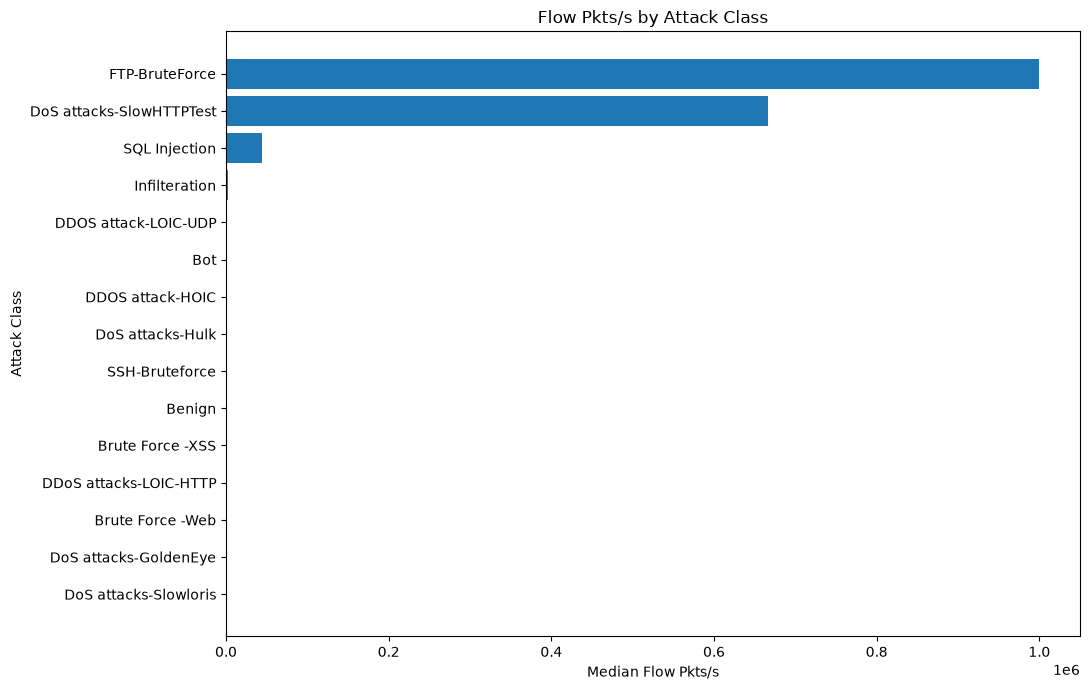

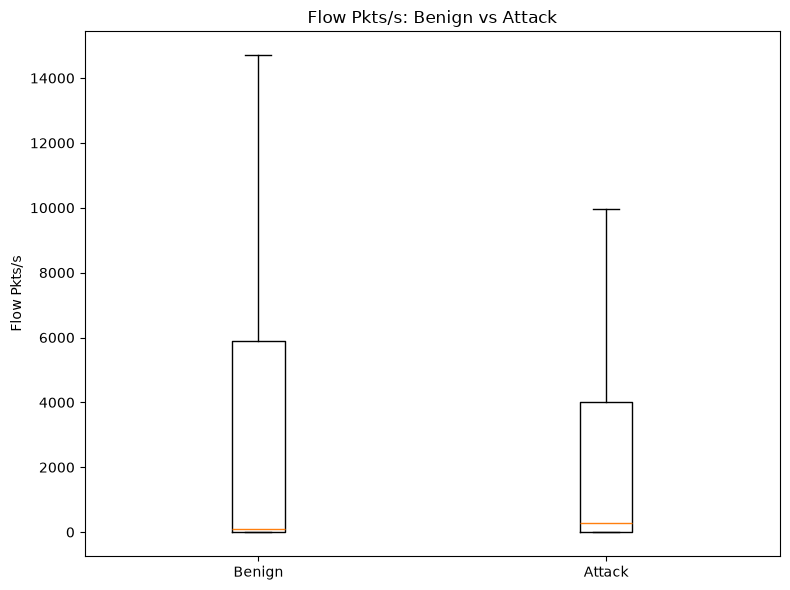

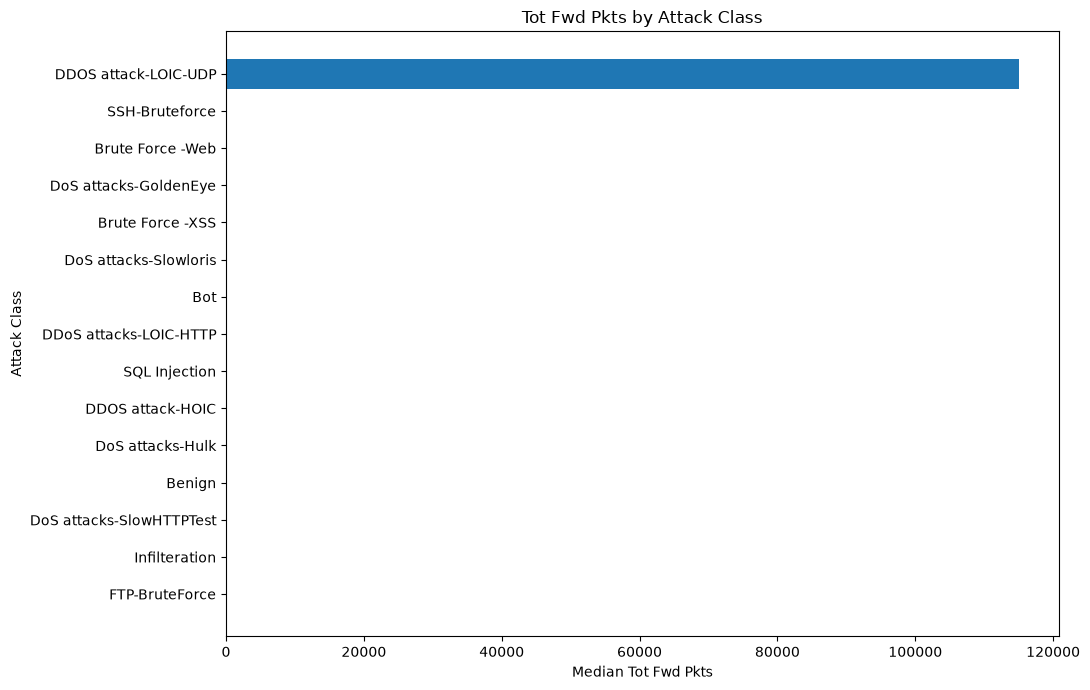

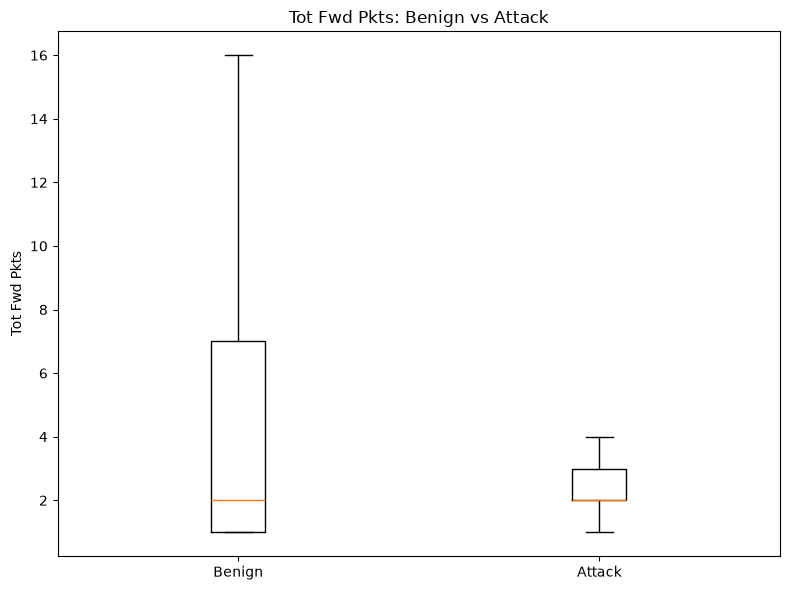

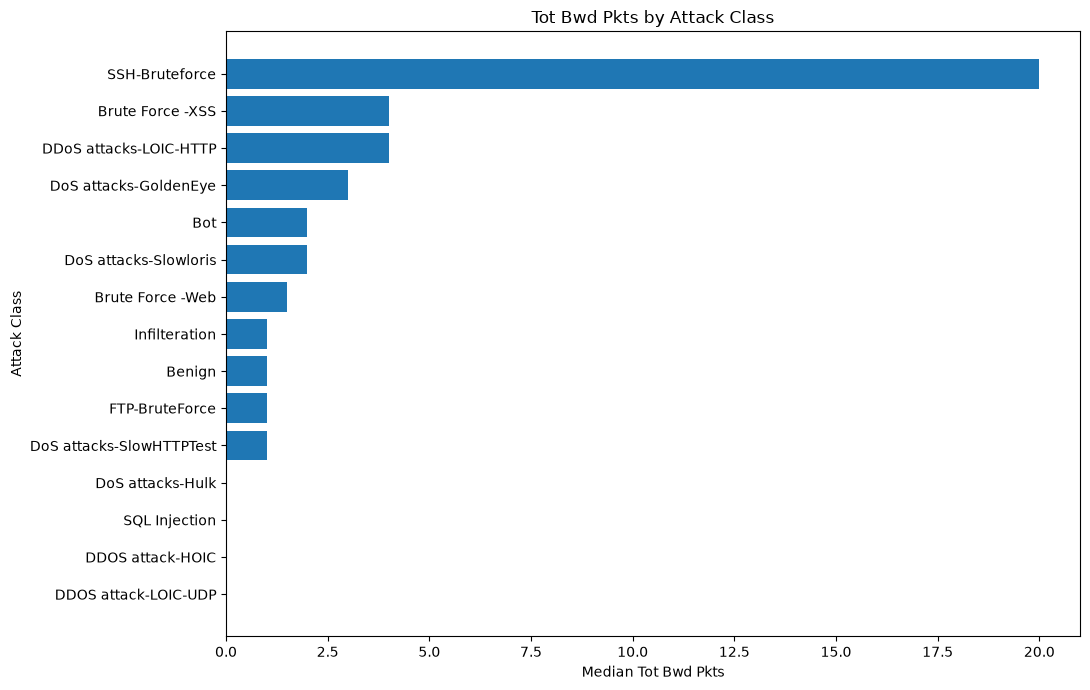

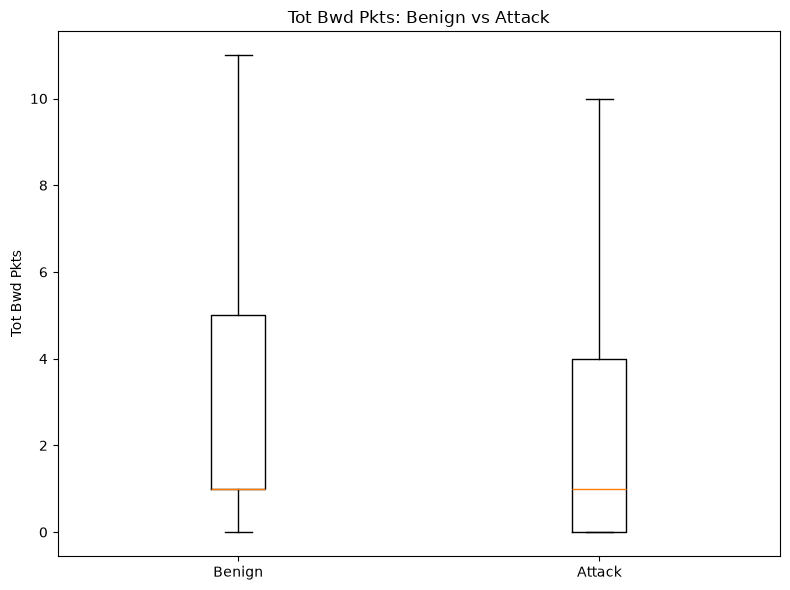


4. PACKET SIZE


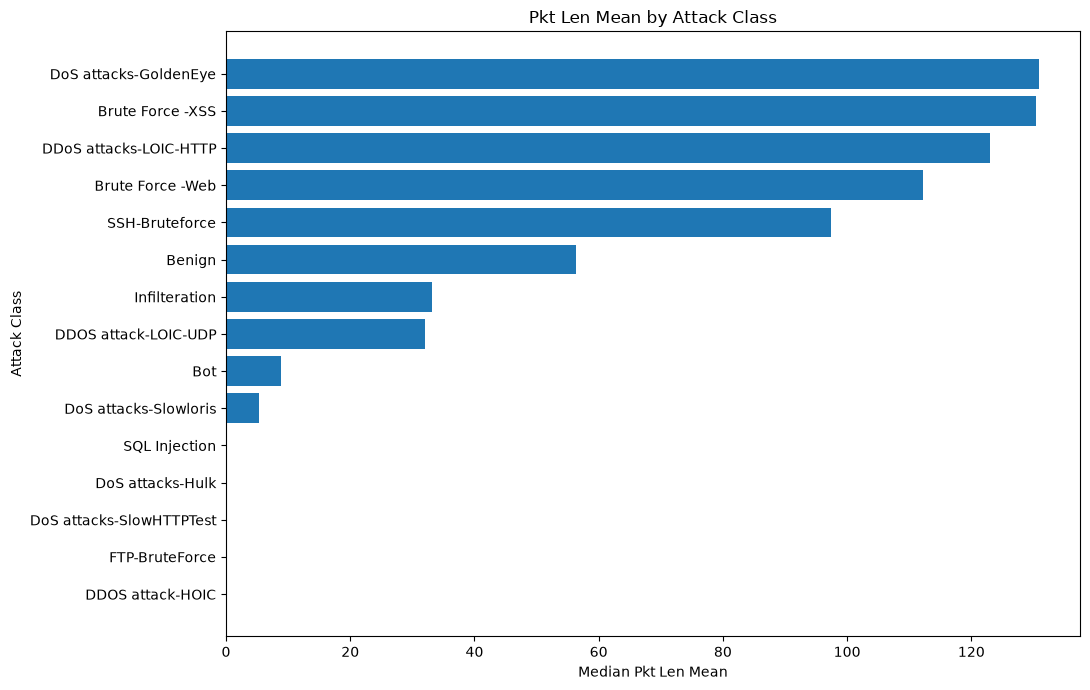

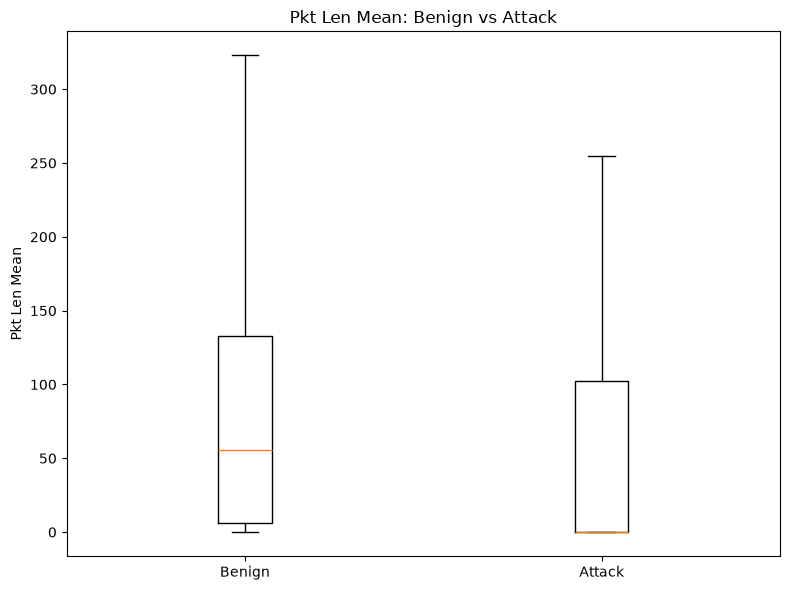

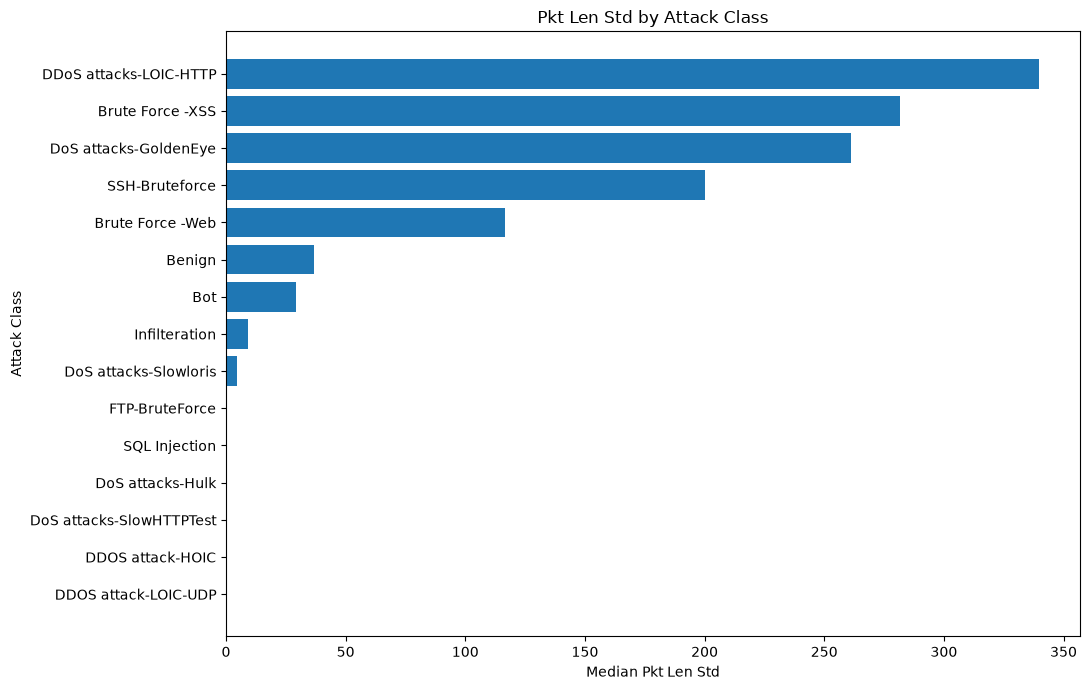

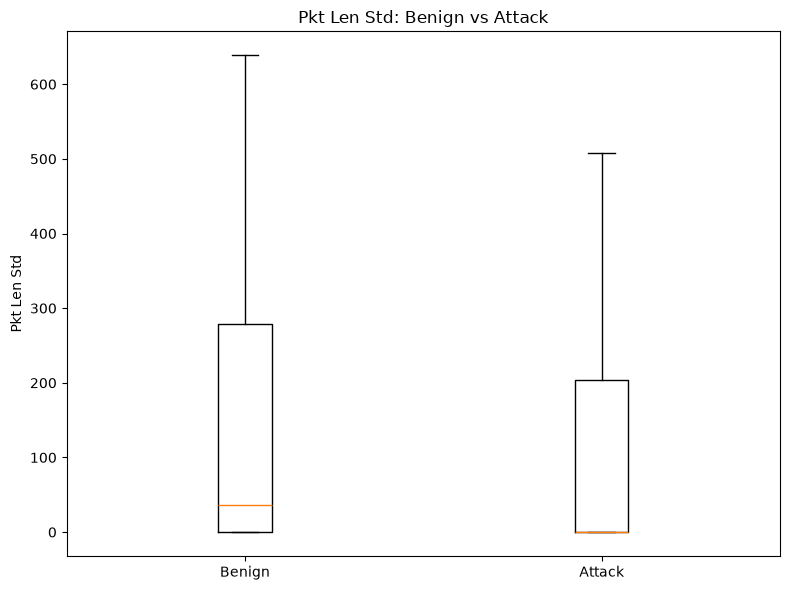

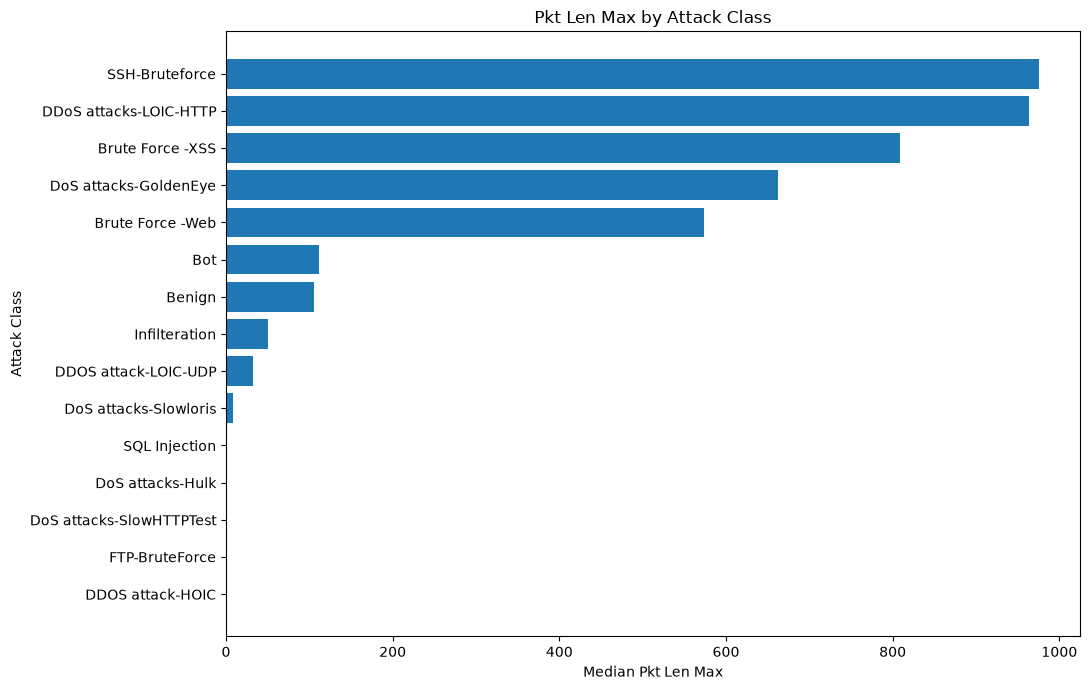

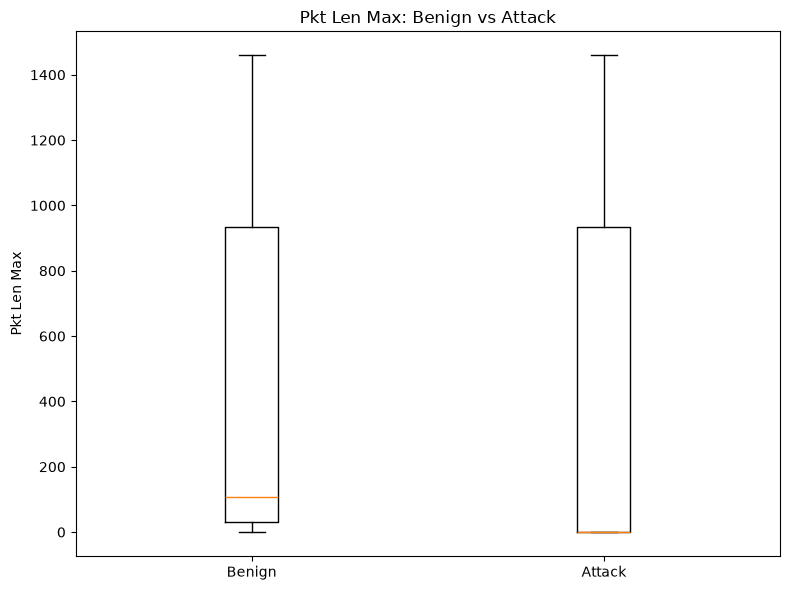

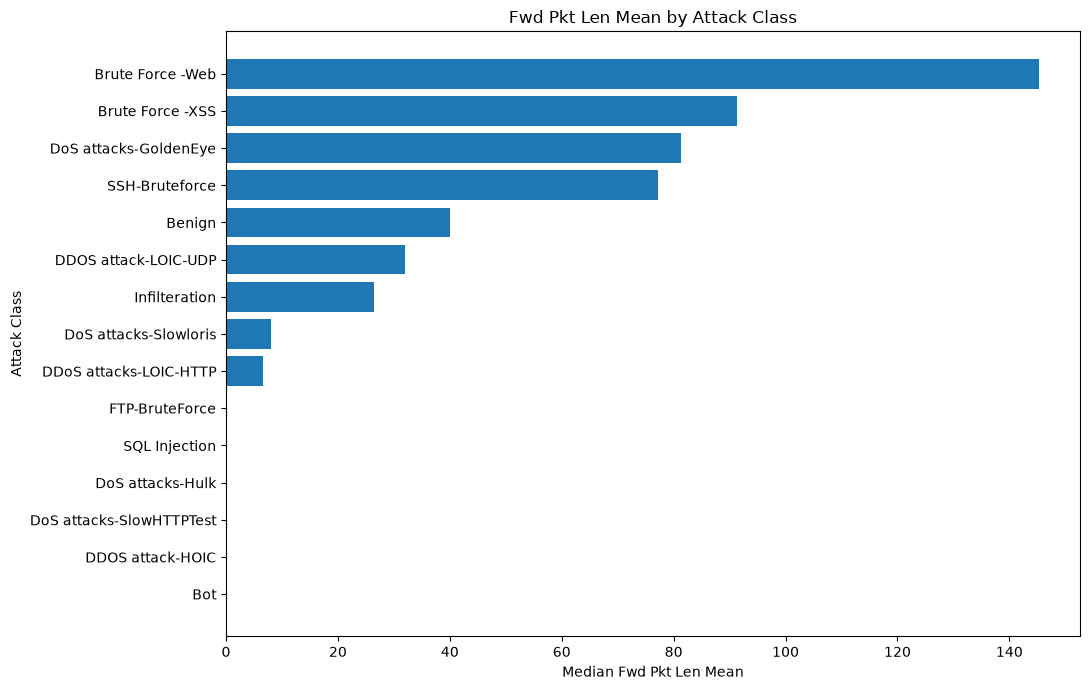

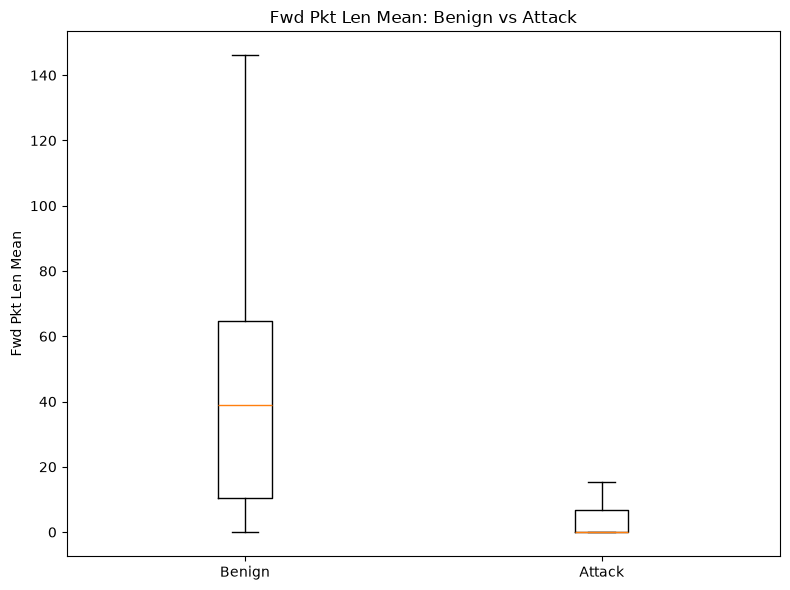

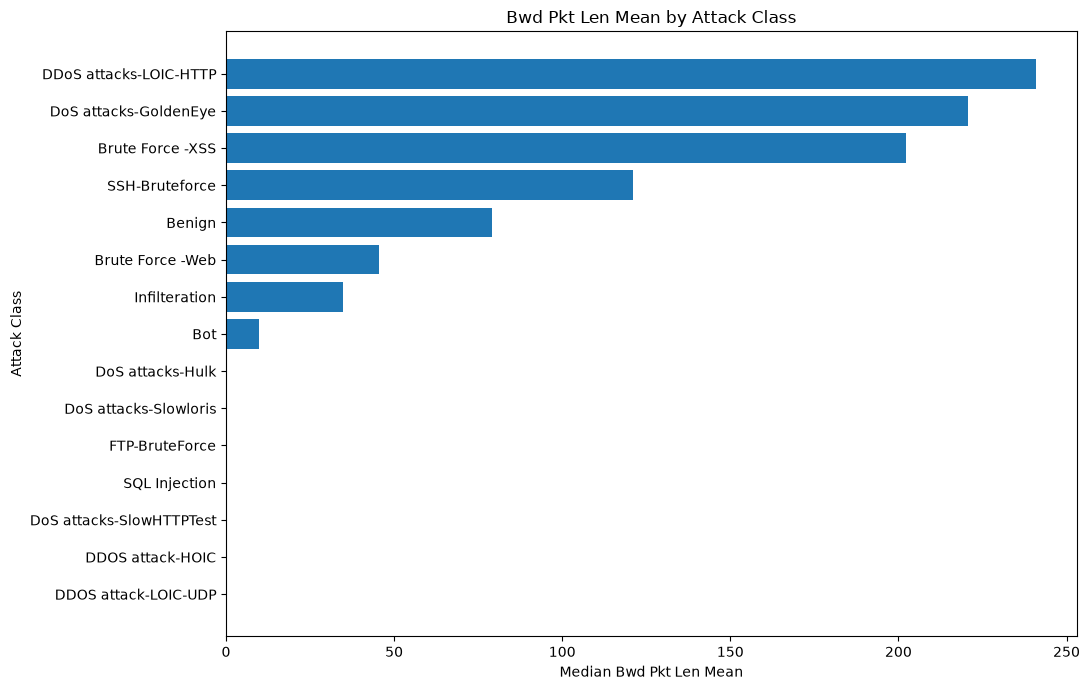

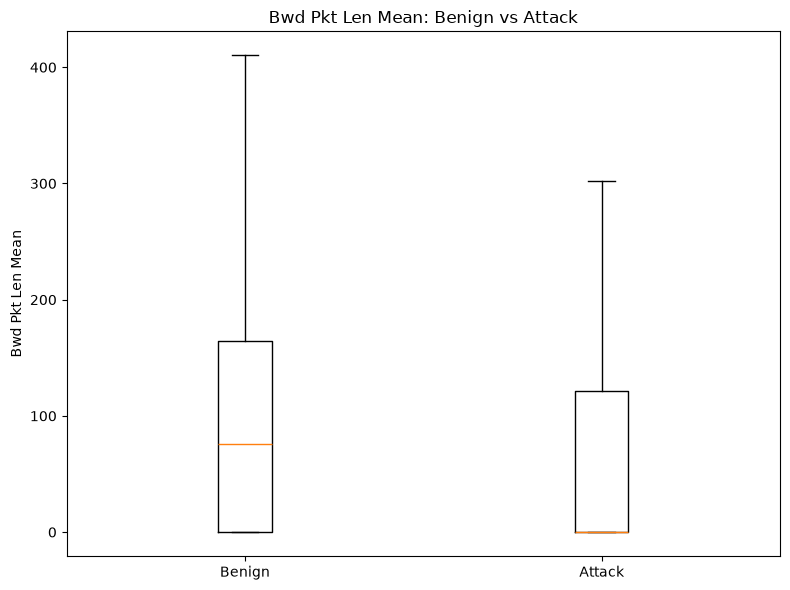


5. IAT / TEMPORAL


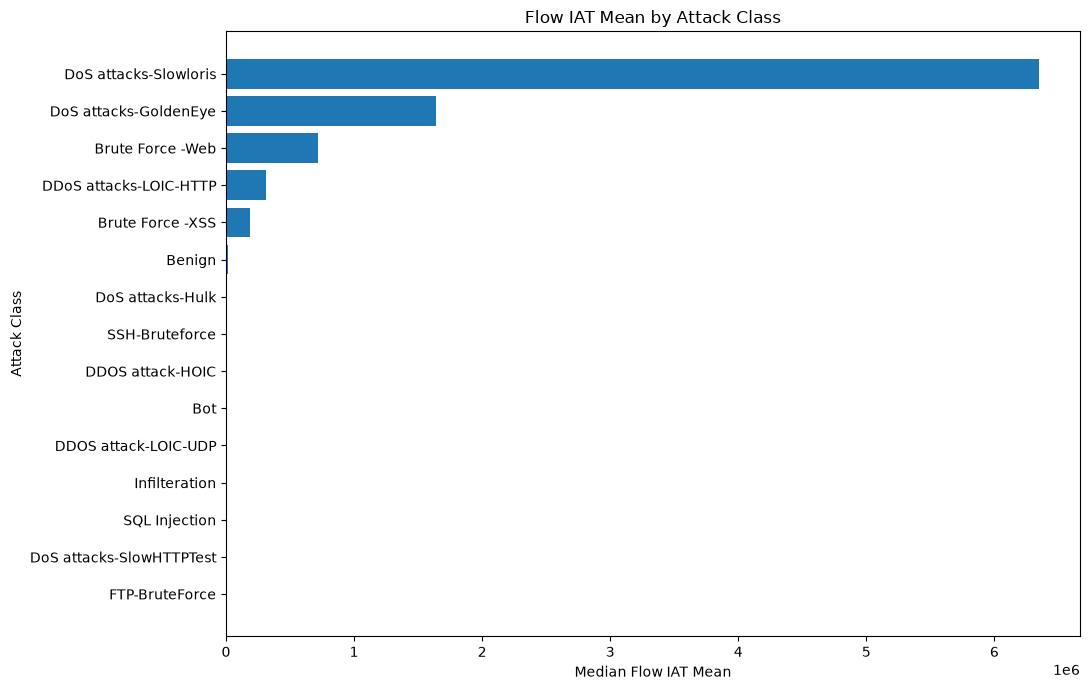

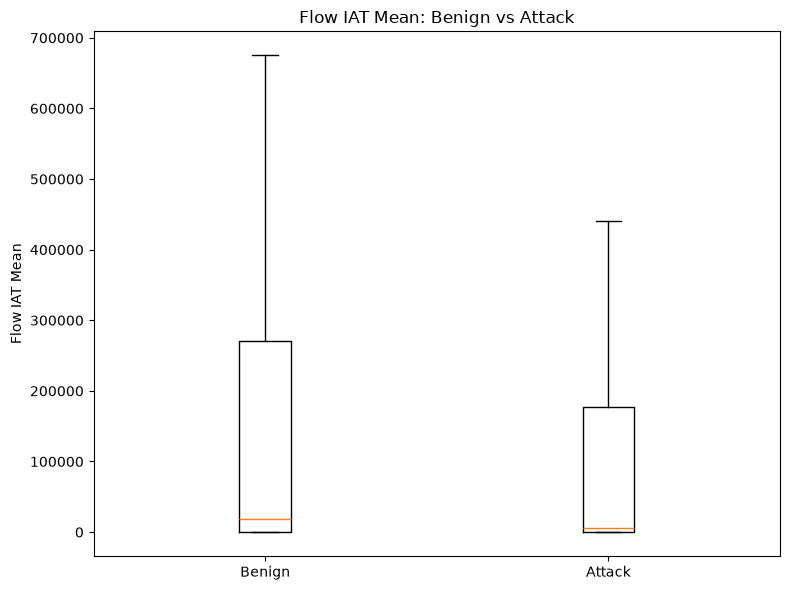

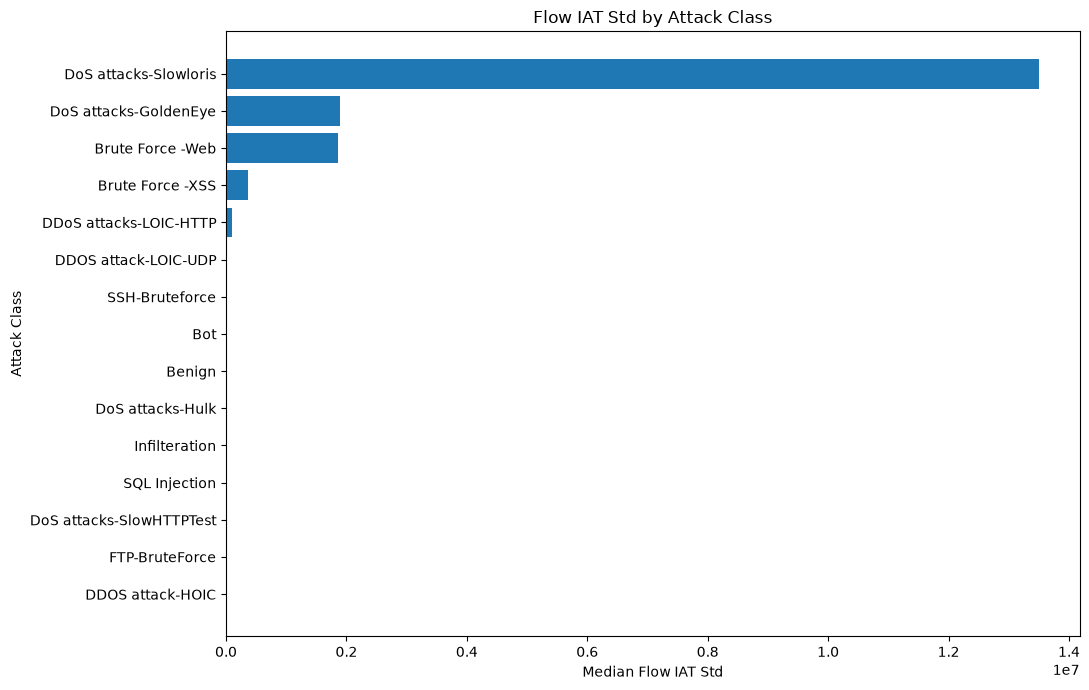

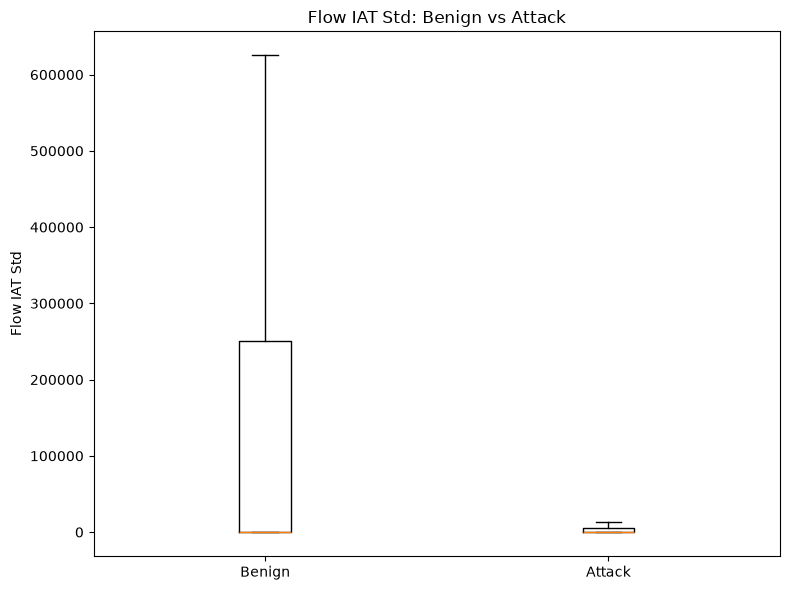

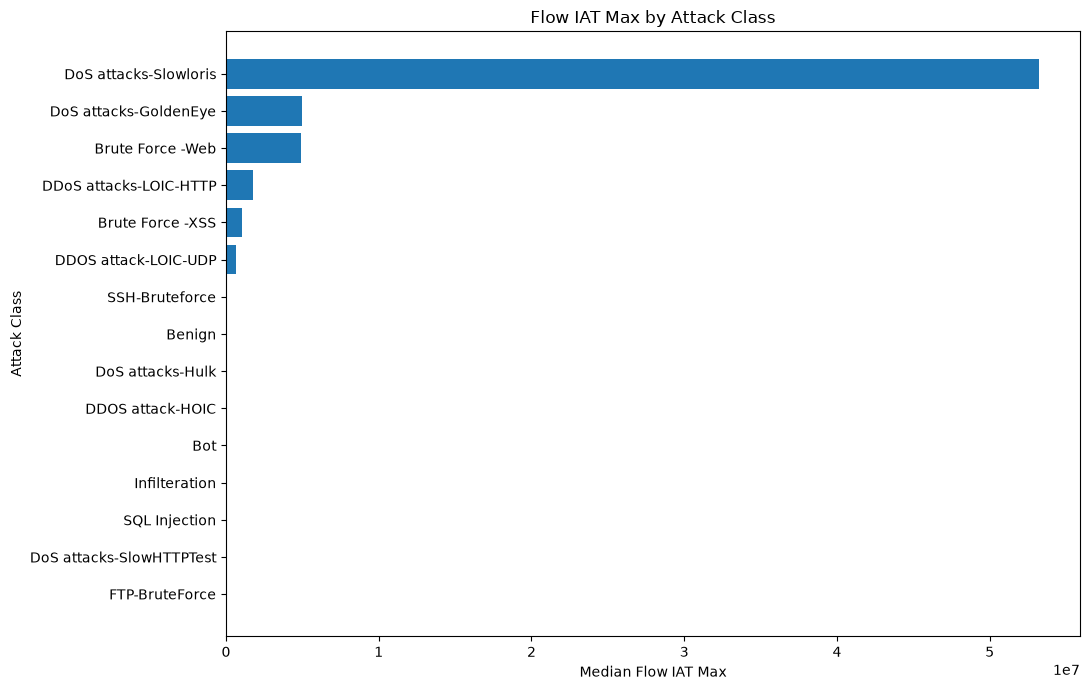

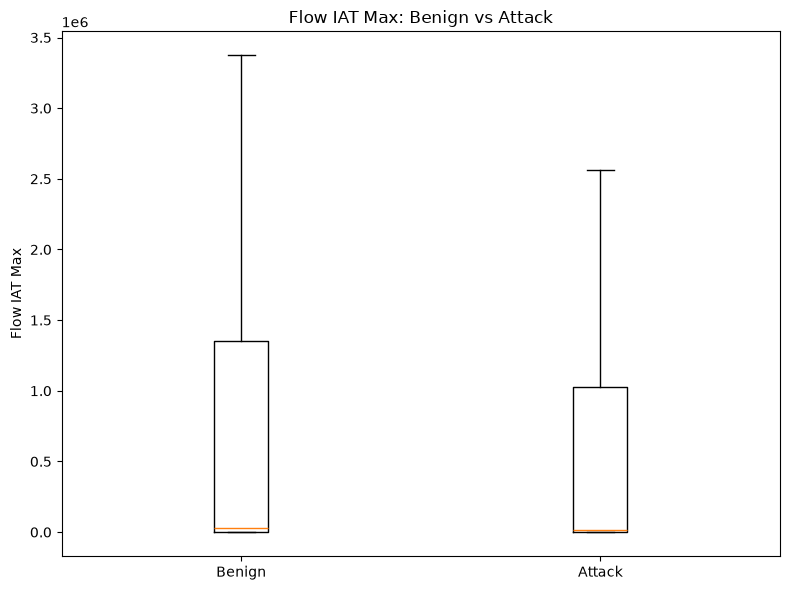

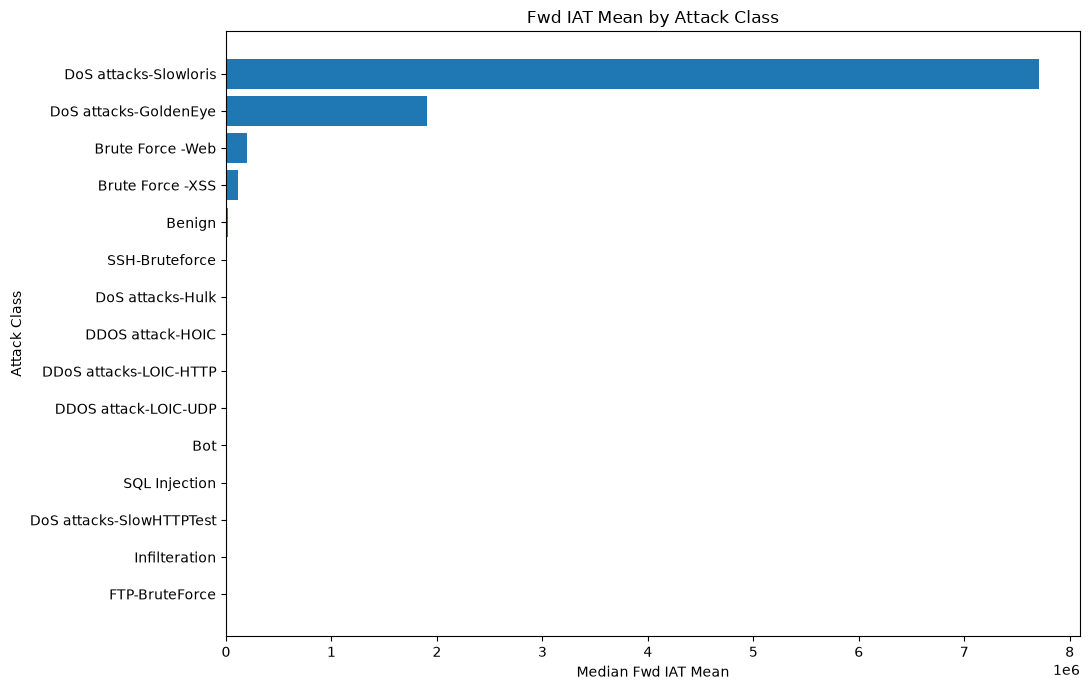

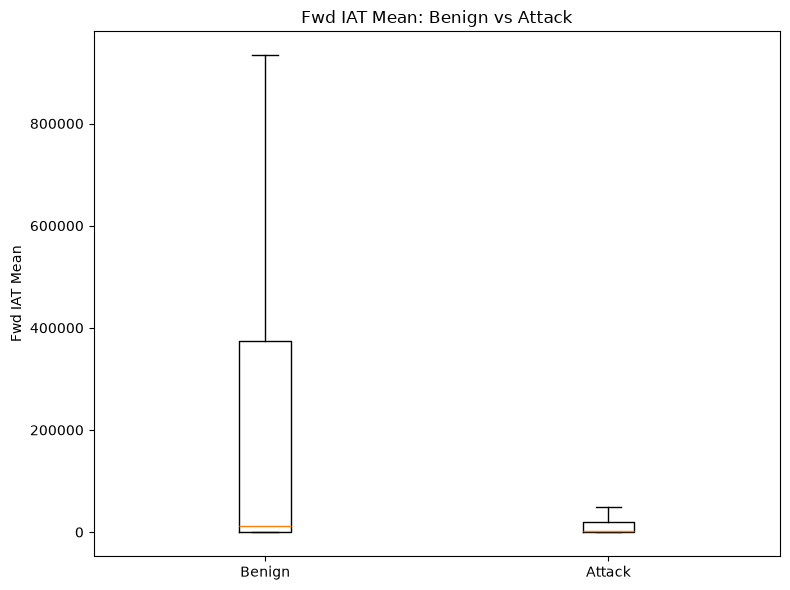

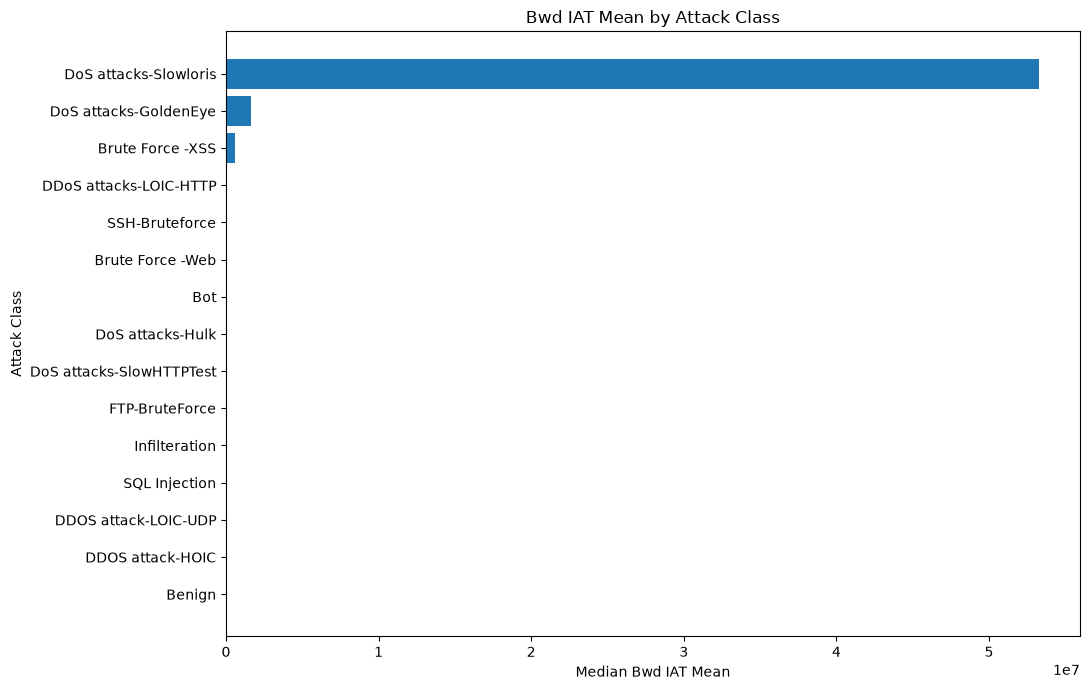

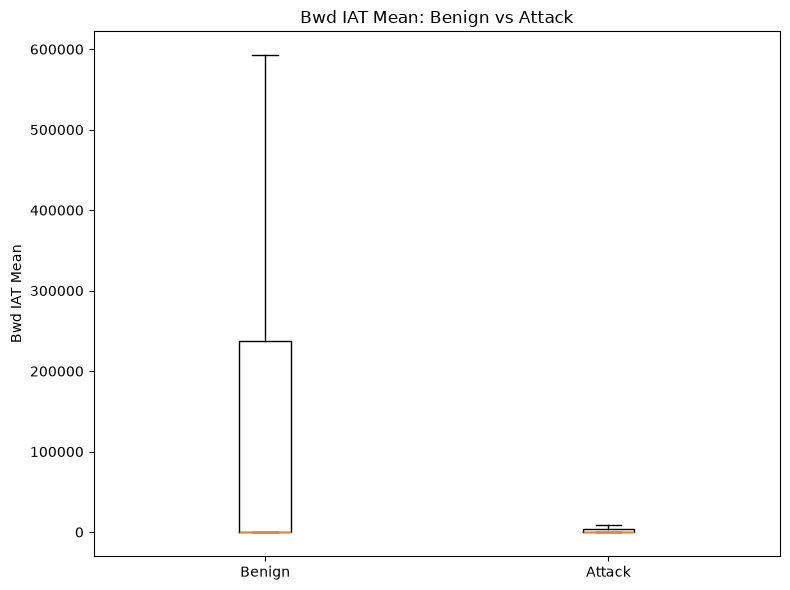


6. TCP FLAGS
                          FIN Flag Cnt  SYN Flag Cnt  RST Flag Cnt  \
Label                                                                
Benign                          0.0056        0.0529        0.1566   
Bot                             0.0000        0.0000        0.5026   
Brute Force -Web                0.0000        0.0000        0.5000   
Brute Force -XSS                0.0000        0.0000        0.6000   
DDOS attack-HOIC                0.0000        0.0000        0.4383   
DDOS attack-LOIC-UDP            0.0000        0.0000        0.0000   
DDoS attacks-LOIC-HTTP          0.0000        0.0000        0.5019   
DoS attacks-GoldenEye           0.0000        0.0000        0.0000   
DoS attacks-Hulk                0.0028        0.0000        0.0000   
DoS attacks-SlowHTTPTest        0.0000        0.0000        0.0000   
DoS attacks-Slowloris           0.0049        0.3252        0.0000   
FTP-BruteForce                  0.0000        0.0000        0.0000   
Infilt

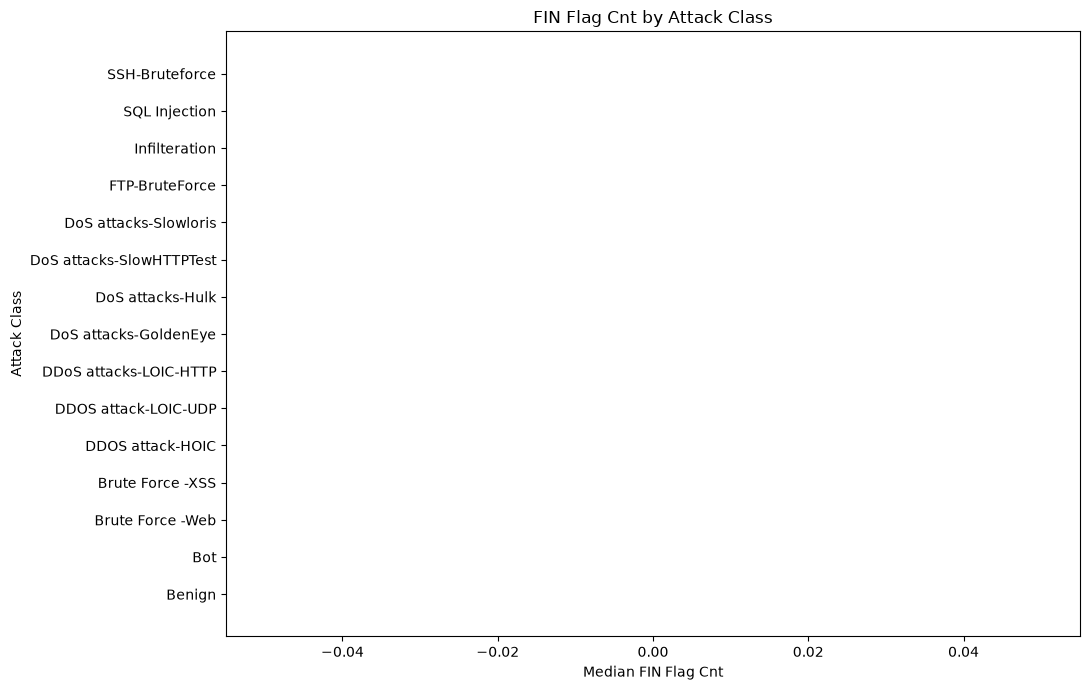

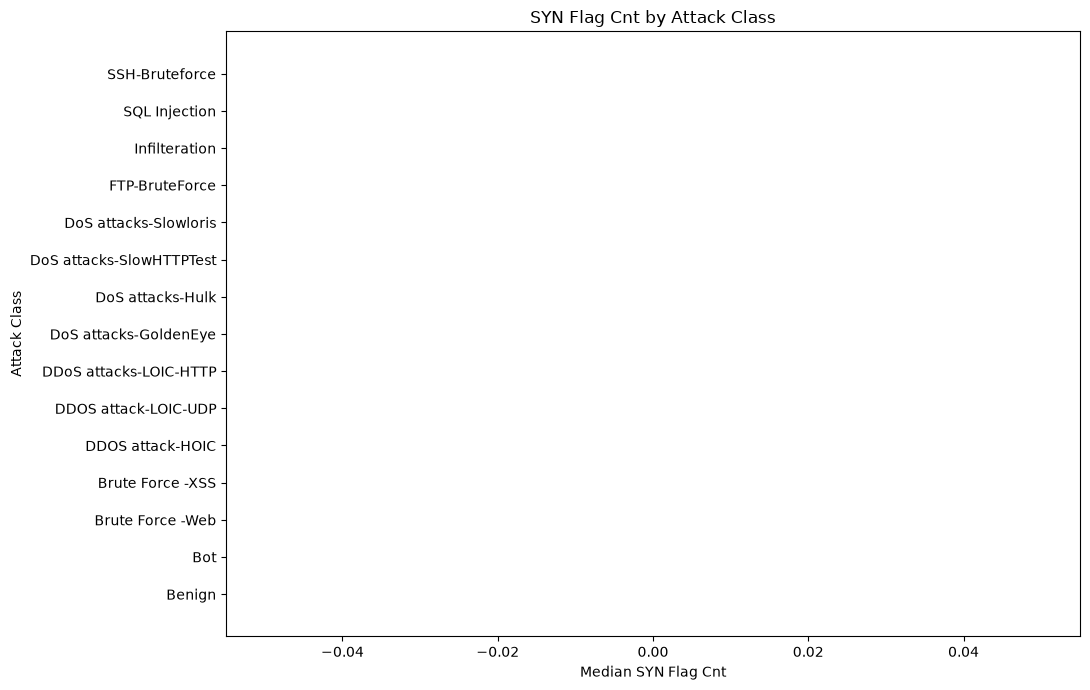

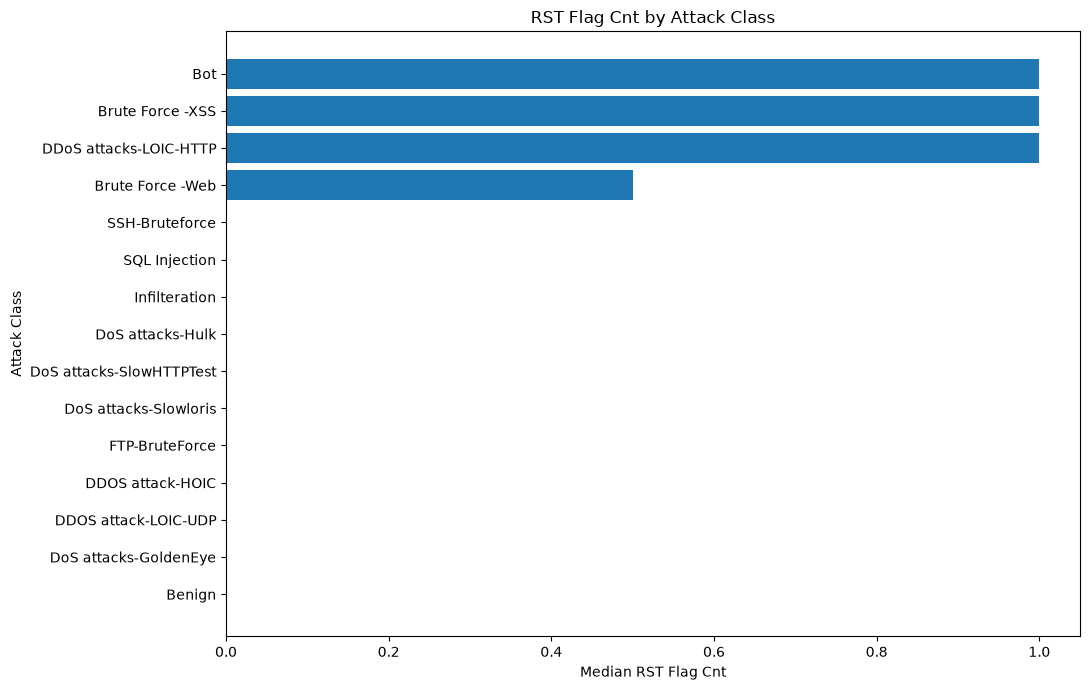

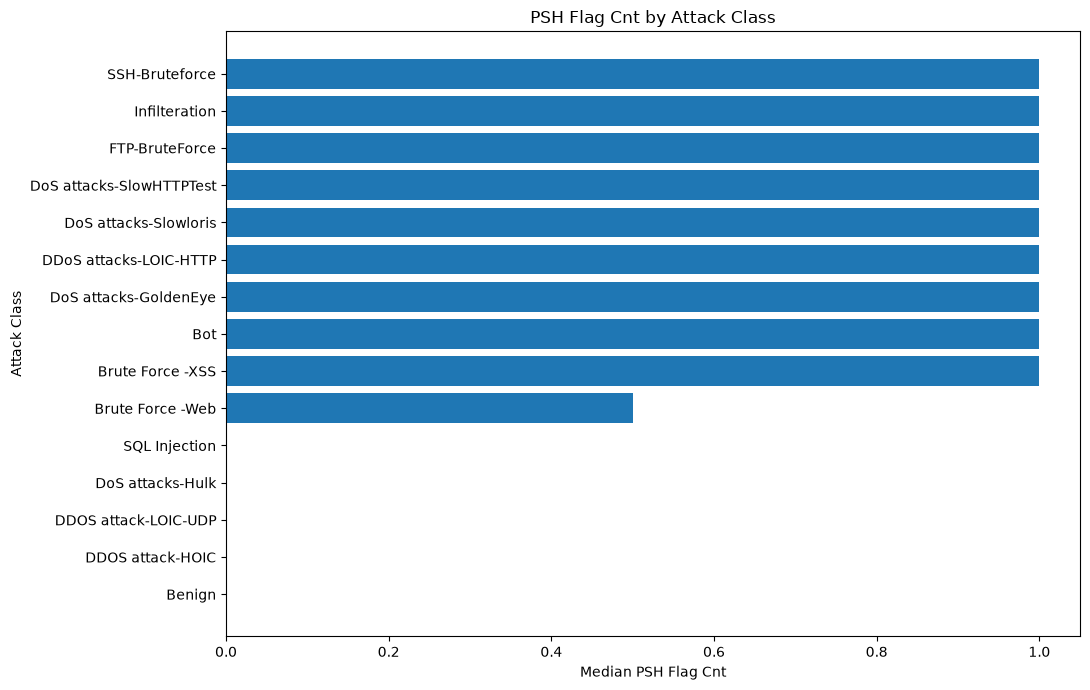

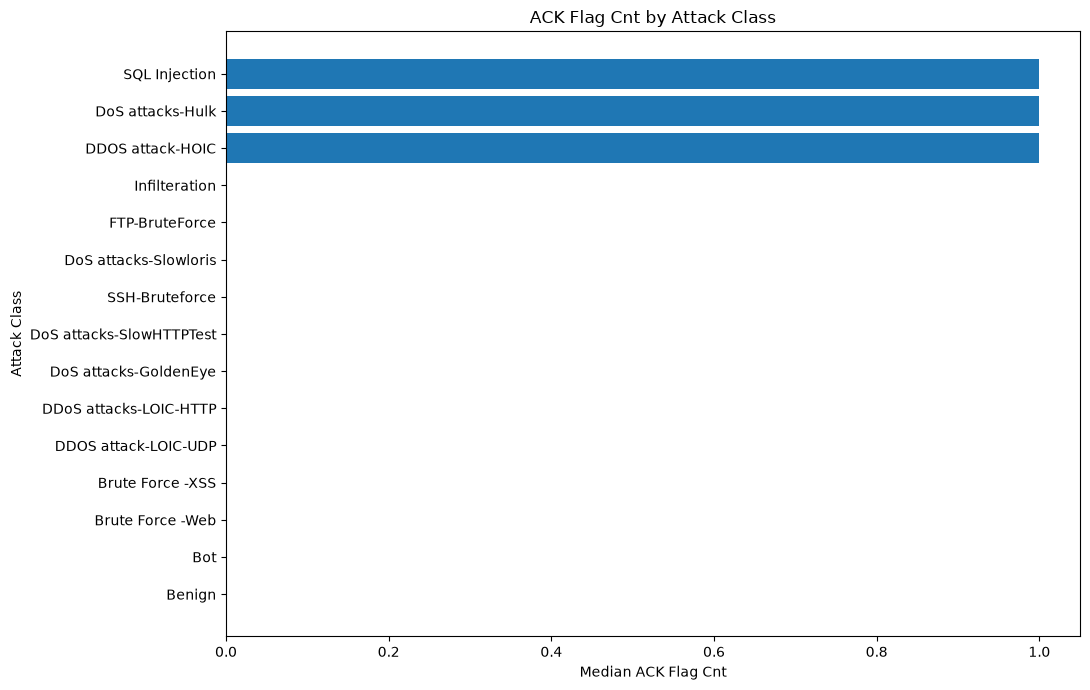

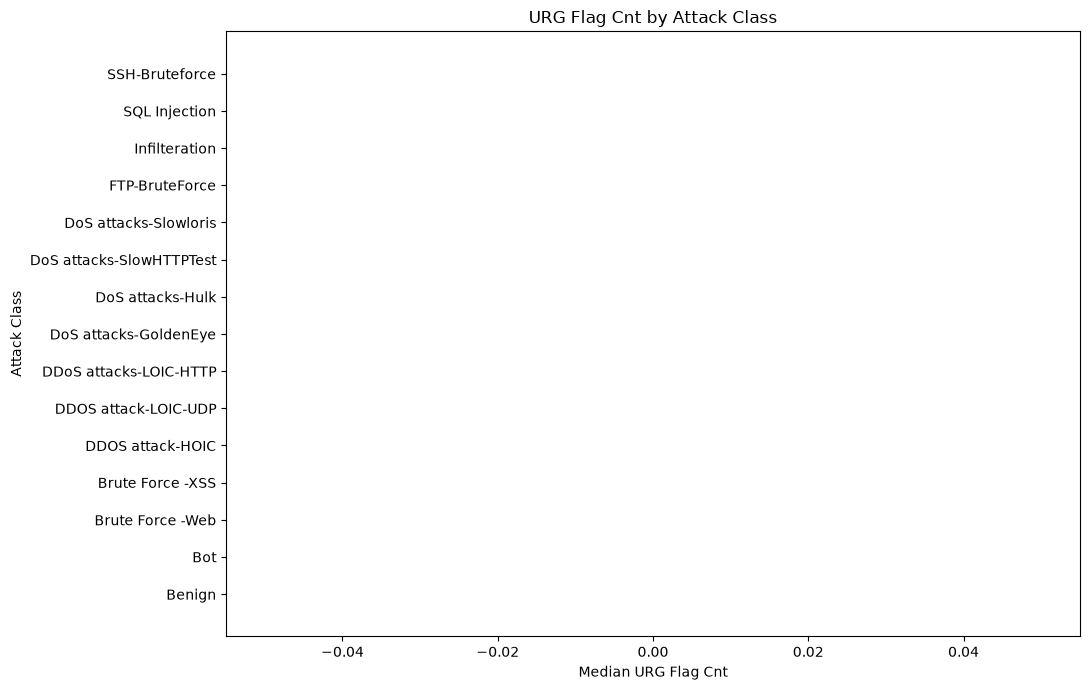

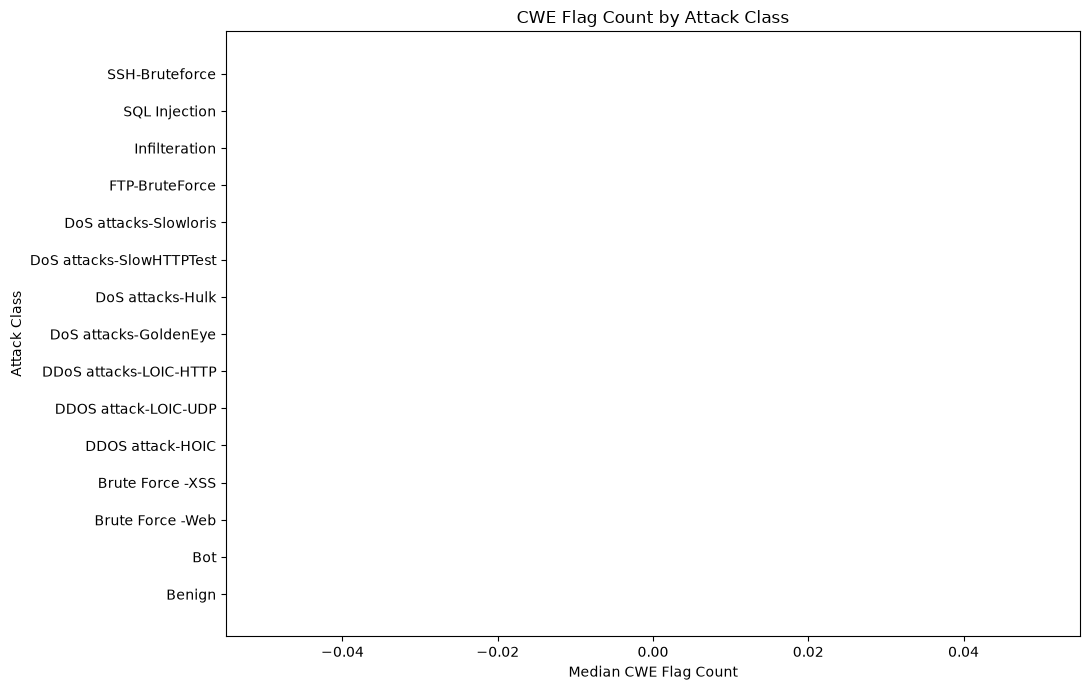

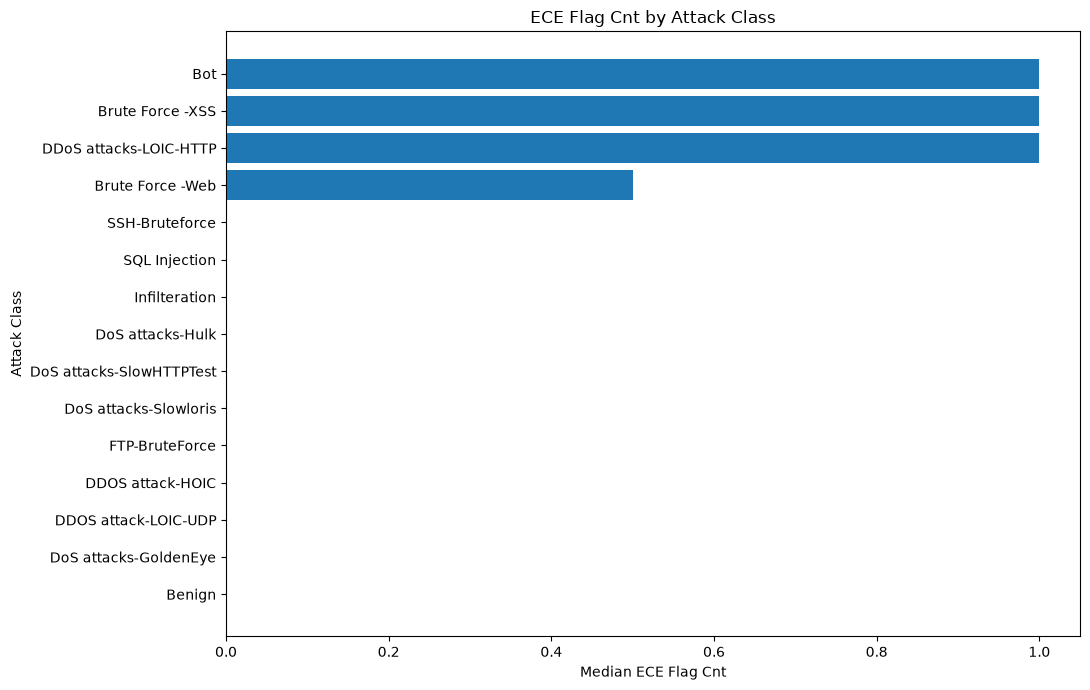


7. ACTIVE / IDLE


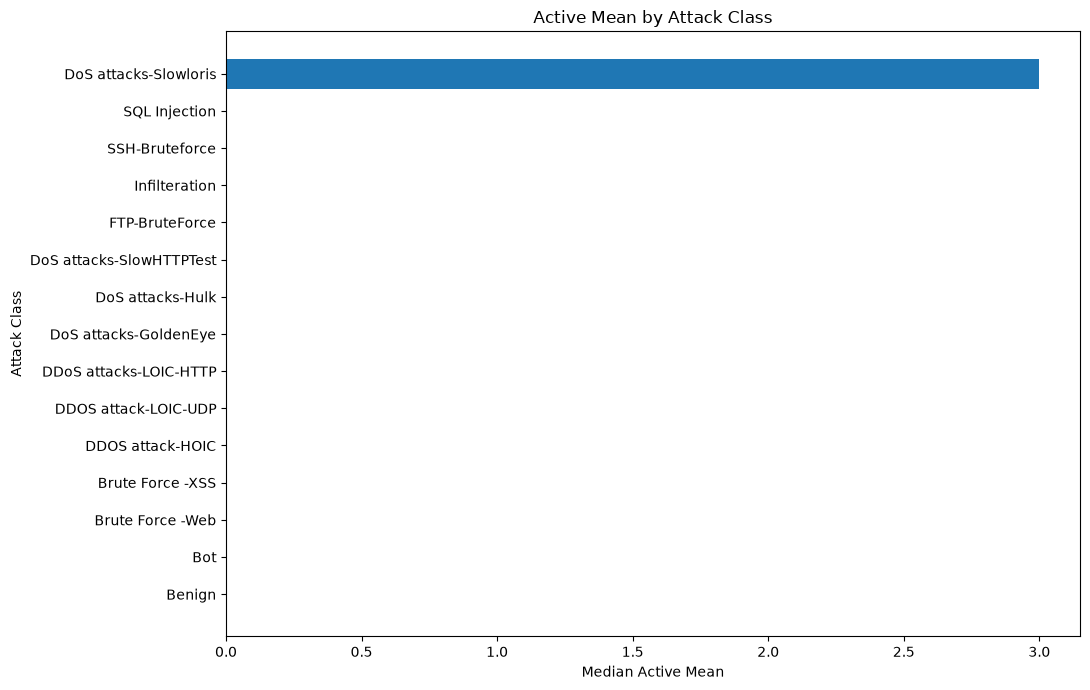

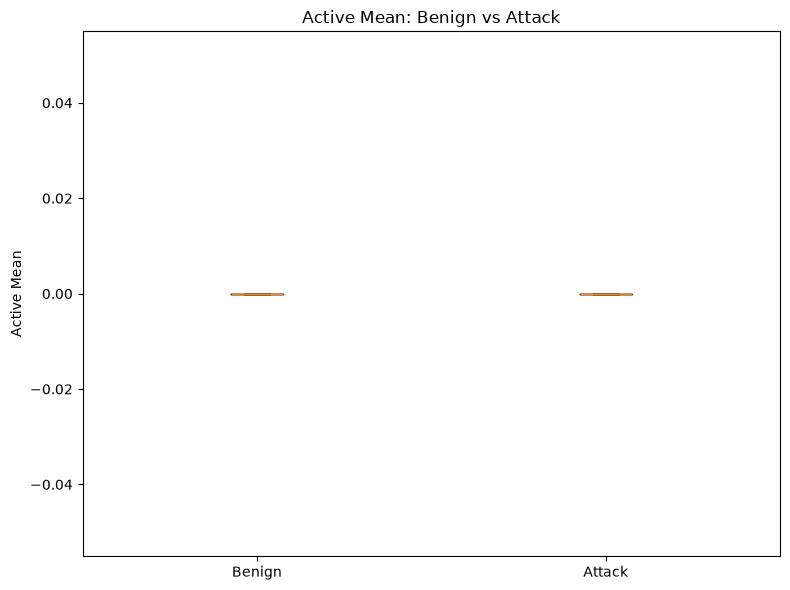

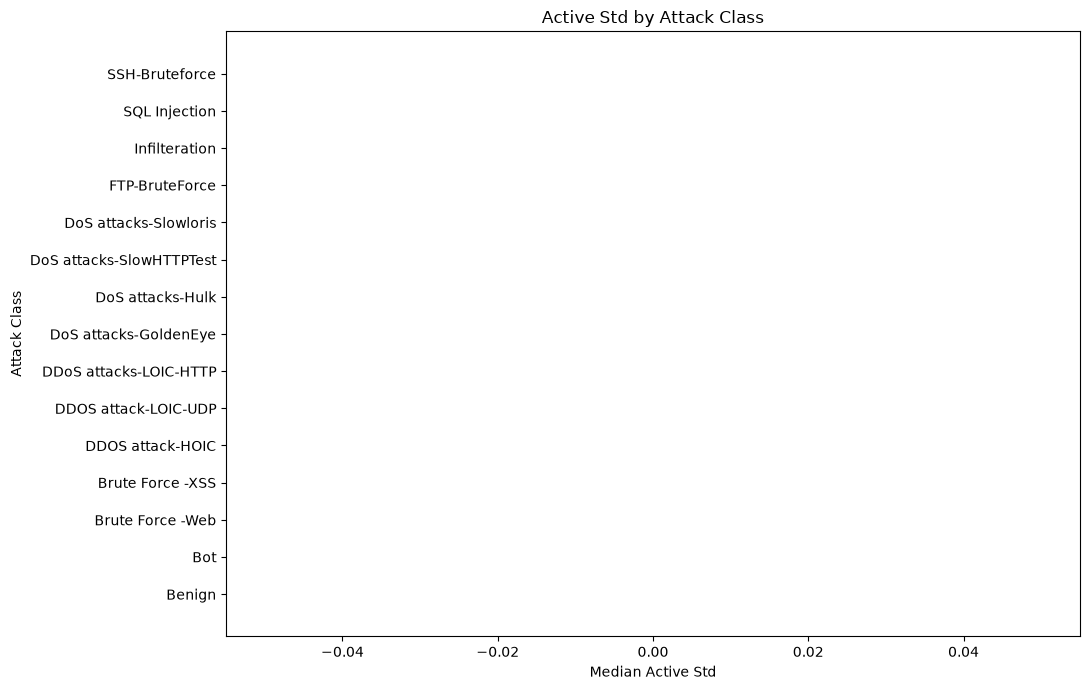

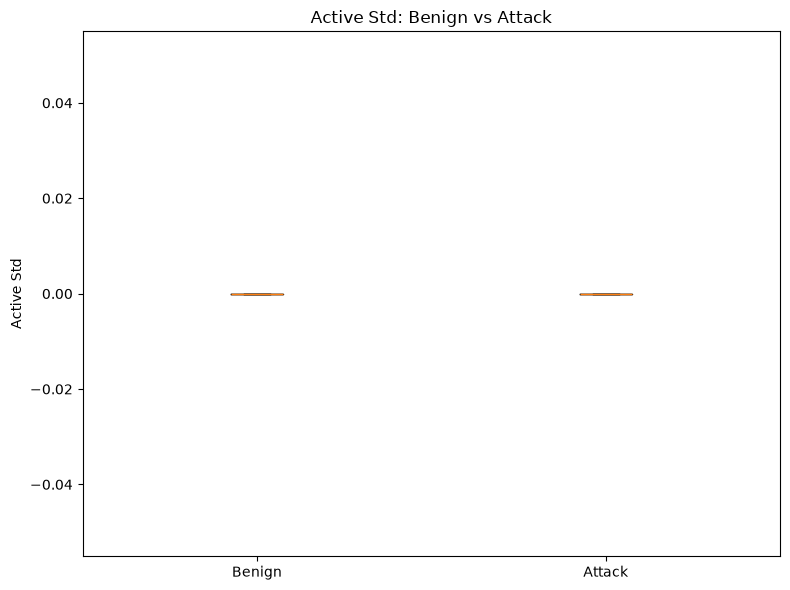

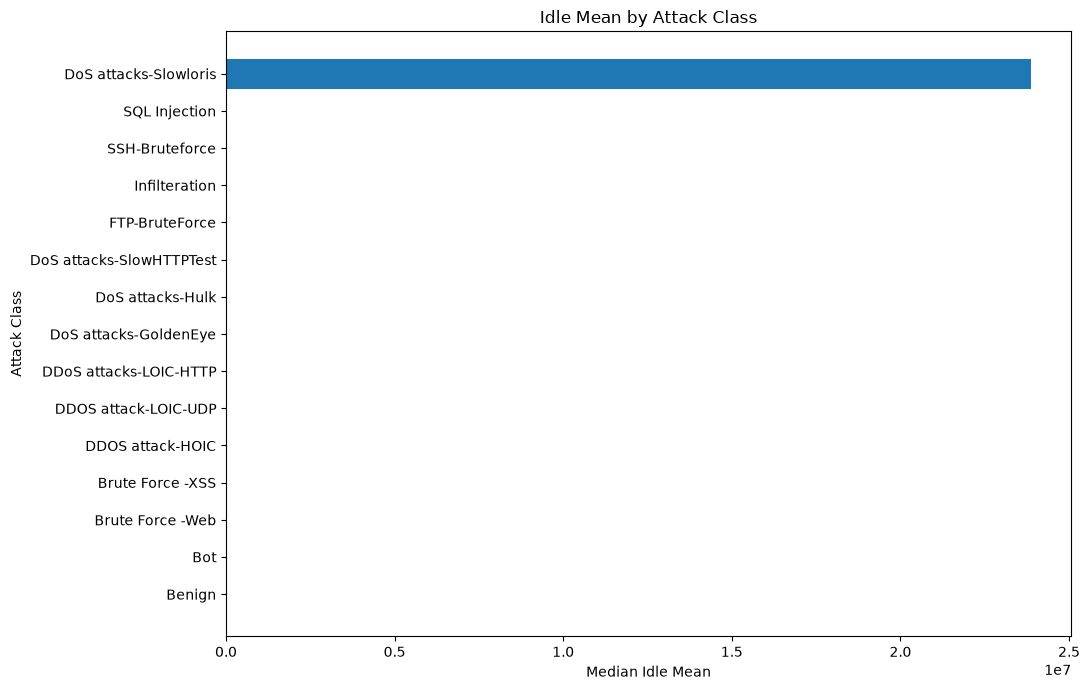

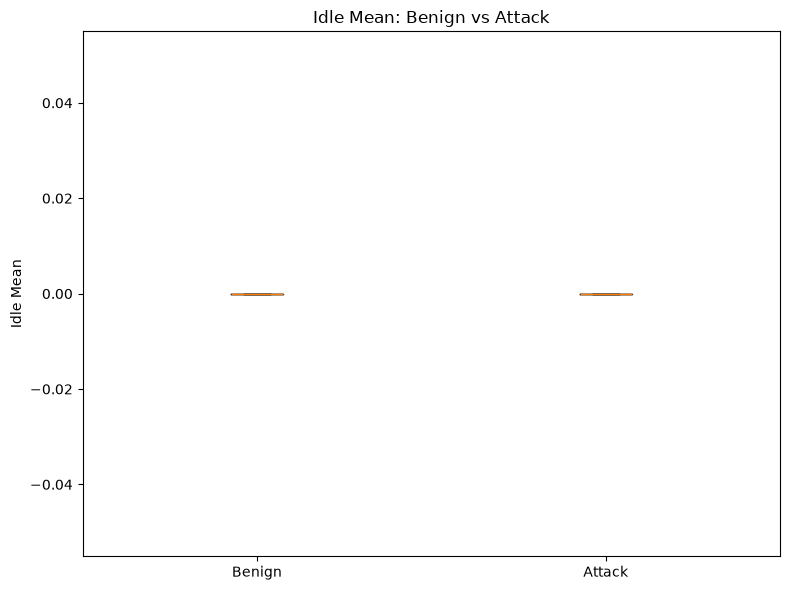

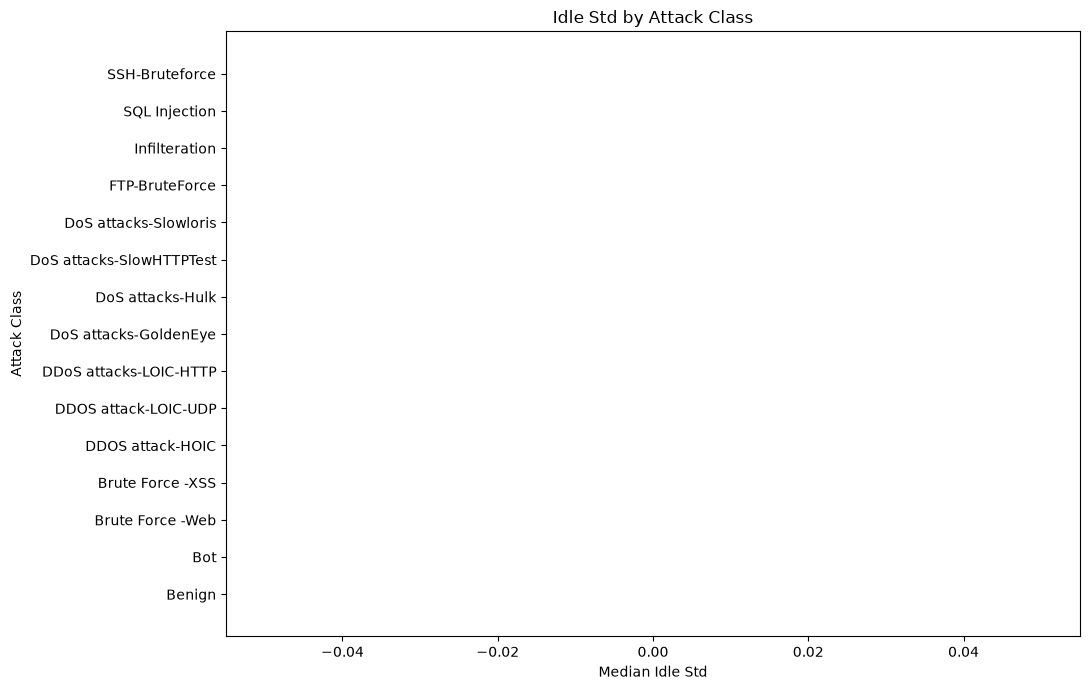

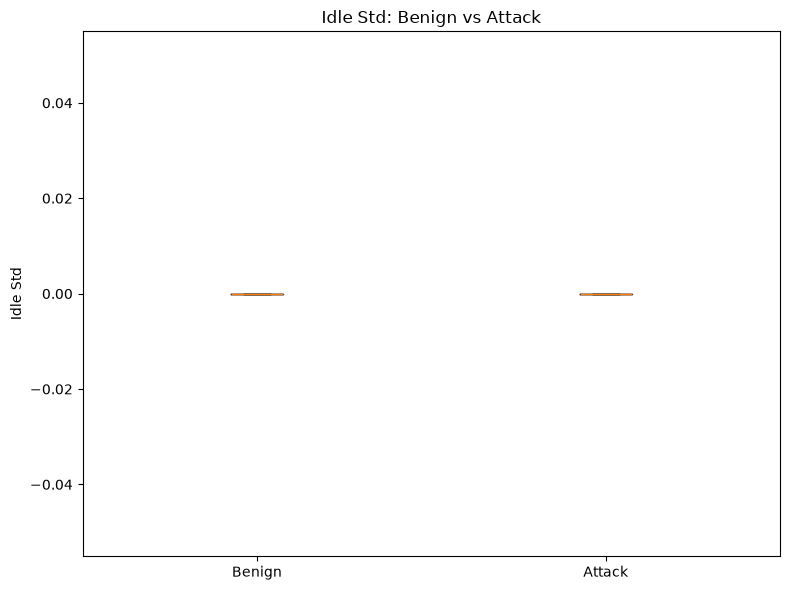


8. BENIGN VS ATTACK
Traffic Type            Attack        Benign  absolute_difference  \
Fwd IAT Min         329.000000     29.000000           300.000000   
Fwd Pkts/s          204.505948     39.780808           164.725140   
Flow Pkts/s         281.571189     81.756121           199.815068   
Fwd Pkt Len Max       0.000000     44.000000           -44.000000   
TotLen Fwd Pkts       0.000000     51.000000           -51.000000   
Flow Byts/s           0.000000   1076.681373         -1076.681373   
Bwd Pkt Len Max       0.000000    104.000000          -104.000000   
Bwd Pkt Len Mean      0.000000     79.000000           -79.000000   
Fwd Pkt Len Mean      0.000000     40.000000           -40.000000   
TotLen Bwd Pkts       0.000000    120.000000          -120.000000   
Pkt Size Avg          0.000000     78.500000           -78.500000   
Flow IAT Std          0.000000    117.185892          -117.185892   
Pkt Len Var           0.000000   1365.333333         -1365.333333   
Pkt Len Max  

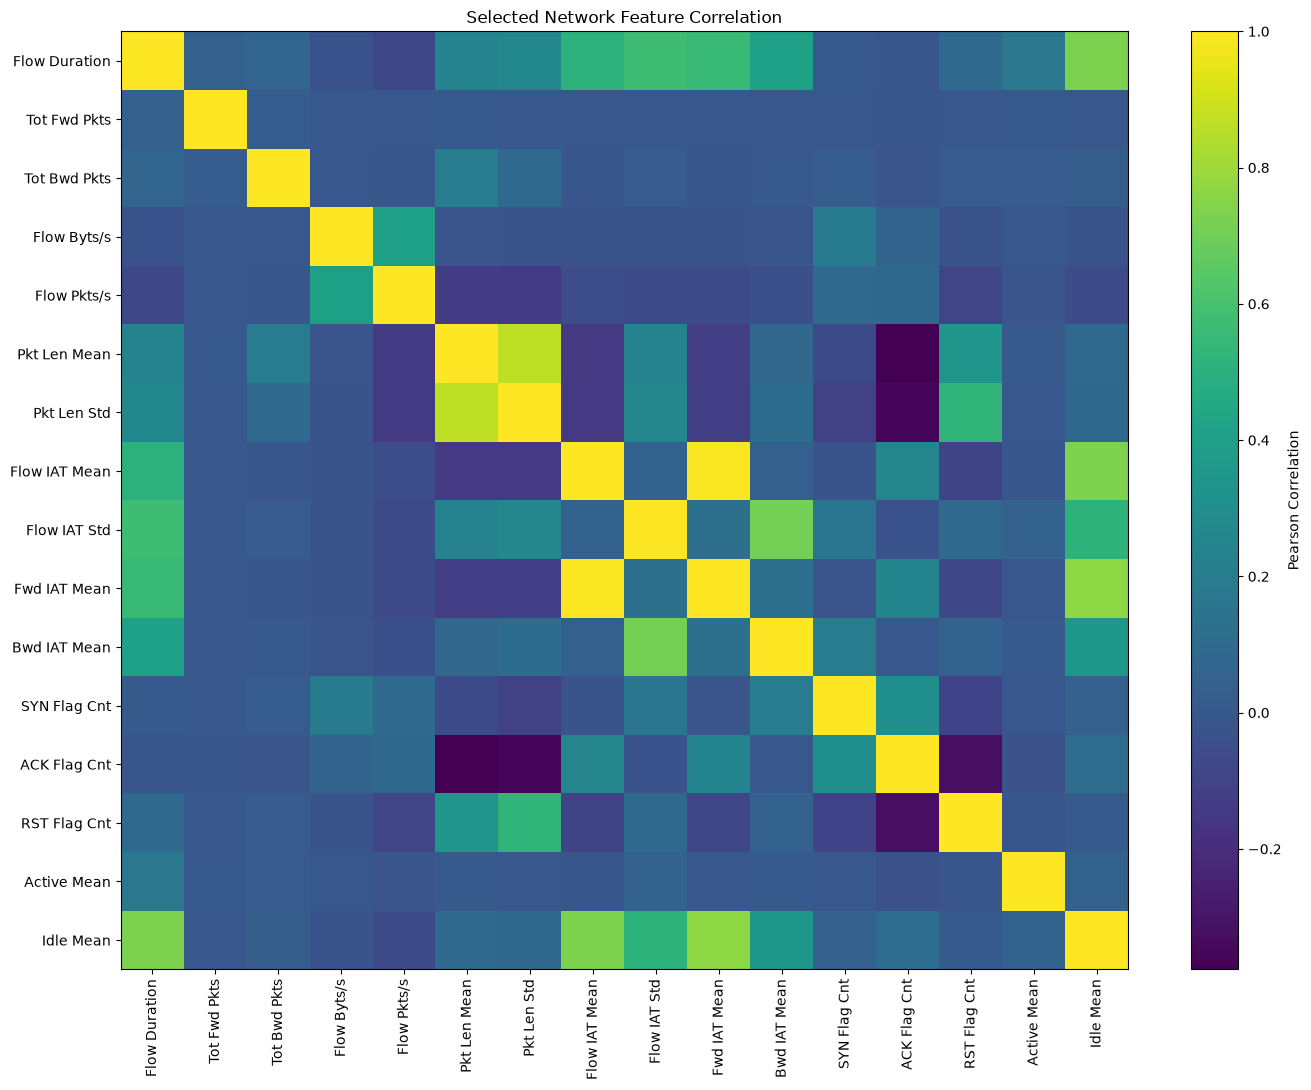


[EDA Feature Candidates]
         feature  benign_median  attack_median  absolute_difference  relative_difference  abs_relative_difference
     Fwd IAT Min      29.000000     329.000000           300.000000            10.344828                10.344828
      Fwd Pkts/s      39.780808     204.505948           164.725140             4.140819                 4.140819
     Flow Pkts/s      81.756121     281.571189           199.815068             2.444038                 2.444038
 Fwd Pkt Len Max      44.000000       0.000000           -44.000000            -1.000000                 1.000000
 TotLen Fwd Pkts      51.000000       0.000000           -51.000000            -1.000000                 1.000000
     Flow Byts/s    1076.681373       0.000000         -1076.681373            -1.000000                 1.000000
 Bwd Pkt Len Max     104.000000       0.000000          -104.000000            -1.000000                 1.000000
Bwd Pkt Len Mean      79.000000       0.000000           -79.0

In [13]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 0. 설정
# ============================================================

PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "packages/network-security-ai/pyproject.toml").is_file())

DATA_QUALITY_DIR = PROJECT_ROOT / "results" / "data_quality"
OUTPUT_DIR = PROJECT_ROOT / "results" / "network_eda"
FIGURE_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_PATH = DATA_QUALITY_DIR / "eda_sample.parquet"
CLASS_DIST_PATH = DATA_QUALITY_DIR / "class_distribution.csv"

TARGET = "Label"
SOURCE_COL = "source_file"

print("Sample:", SAMPLE_PATH)
print("Output:", OUTPUT_DIR)


# ============================================================
# 1. 데이터 로드
# ============================================================

df = pd.read_parquet(SAMPLE_PATH)
class_dist = pd.read_csv(CLASS_DIST_PATH)

df.columns = df.columns.str.strip()
class_dist.columns = class_dist.columns.str.strip()

df[TARGET] = df[TARGET].astype(str).str.strip()

print("\n[EDA Sample]")
print("Rows   :", len(df))
print("Columns:", len(df.columns))

print("\n[Columns]")
print(df.columns.tolist())

print("\n[Labels]")
print(df[TARGET].value_counts())

print("\n[Class distribution columns]")
print(class_dist.columns.tolist())


# ============================================================
# 2. 숫자형 데이터 정리
# ============================================================

# inf -> NaN
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

df[numeric_cols] = df[numeric_cols].replace(
    [np.inf, -np.inf],
    np.nan
)

# EDA용 Benign / Attack 이진 그룹
df["Traffic Type"] = np.where(
    df[TARGET].str.lower().eq("benign"),
    "Benign",
    "Attack"
)

print("\n[Traffic Type]")
print(df["Traffic Type"].value_counts())


# ============================================================
# 3. Feature 그룹 정의
# ============================================================

traffic_features = [
    "Flow Duration",
    "Tot Fwd Pkts",
    "Tot Bwd Pkts",
    "TotLen Fwd Pkts",
    "TotLen Bwd Pkts",
    "Flow Byts/s",
    "Flow Pkts/s",
    "Fwd Pkts/s",
    "Bwd Pkts/s",
    "Down/Up Ratio",
]

packet_features = [
    "Fwd Pkt Len Max",
    "Fwd Pkt Len Min",
    "Fwd Pkt Len Mean",
    "Fwd Pkt Len Std",
    "Bwd Pkt Len Max",
    "Bwd Pkt Len Min",
    "Bwd Pkt Len Mean",
    "Bwd Pkt Len Std",
    "Pkt Len Min",
    "Pkt Len Max",
    "Pkt Len Mean",
    "Pkt Len Std",
    "Pkt Len Var",
    "Pkt Size Avg",
]

iat_features = [
    "Flow IAT Mean",
    "Flow IAT Std",
    "Flow IAT Max",
    "Flow IAT Min",
    "Fwd IAT Tot",
    "Fwd IAT Mean",
    "Fwd IAT Std",
    "Fwd IAT Max",
    "Fwd IAT Min",
    "Bwd IAT Tot",
    "Bwd IAT Mean",
    "Bwd IAT Std",
    "Bwd IAT Max",
    "Bwd IAT Min",
]

flag_features = [
    "FIN Flag Cnt",
    "SYN Flag Cnt",
    "RST Flag Cnt",
    "PSH Flag Cnt",
    "ACK Flag Cnt",
    "URG Flag Cnt",
    "CWE Flag Count",
    "ECE Flag Cnt",
]

activity_features = [
    "Active Mean",
    "Active Std",
    "Active Max",
    "Active Min",
    "Idle Mean",
    "Idle Std",
    "Idle Max",
    "Idle Min",
]


# 실제 존재하는 컬럼만 사용
def existing_features(features):
    return [col for col in features if col in df.columns]


traffic_features = existing_features(traffic_features)
packet_features = existing_features(packet_features)
iat_features = existing_features(iat_features)
flag_features = existing_features(flag_features)
activity_features = existing_features(activity_features)

analysis_features = list(
    dict.fromkeys(
        traffic_features
        + packet_features
        + iat_features
        + flag_features
        + activity_features
    )
)

print("\n[Feature Groups]")
print("Traffic :", len(traffic_features))
print("Packet  :", len(packet_features))
print("IAT     :", len(iat_features))
print("Flags   :", len(flag_features))
print("Activity:", len(activity_features))
print("Total   :", len(analysis_features))


# ============================================================
# 4. 공통 함수
# ============================================================

def save_current_figure(filename):
    plt.tight_layout()
    plt.savefig(
        FIGURE_DIR / filename,
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()


def label_summary(data, features):
    """
    공격 클래스별 count / mean / median / std
    """
    if not features:
        return pd.DataFrame()

    summary = (
        data.groupby(TARGET)[features]
        .agg(["count", "mean", "median", "std"])
    )

    return summary


def binary_summary(data, features):
    """
    Benign vs Attack 비교
    """
    if not features:
        return pd.DataFrame()

    summary = (
        data.groupby("Traffic Type")[features]
        .agg(["count", "mean", "median", "std"])
    )

    return summary


def plot_class_median(data, feature, filename):
    """
    클래스별 median bar chart
    """

    temp = (
        data.groupby(TARGET)[feature]
        .median()
        .dropna()
        .sort_values()
    )

    if temp.empty:
        return

    plt.figure(figsize=(11, 7))
    plt.barh(temp.index, temp.values)

    plt.xlabel(f"Median {feature}")
    plt.ylabel("Attack Class")
    plt.title(f"{feature} by Attack Class")

    save_current_figure(filename)


def plot_binary_boxplot(data, feature, filename):
    """
    Benign vs Attack boxplot.

    극단값으로 그래프가 망가지는 것을 막기 위해
    시각화에만 1~99 percentile 범위를 사용한다.
    원본 데이터 자체를 삭제하지 않는다.
    """

    temp = data[["Traffic Type", feature]].dropna().copy()

    if temp.empty:
        return

    low = temp[feature].quantile(0.01)
    high = temp[feature].quantile(0.99)

    temp = temp[
        temp[feature].between(low, high)
    ]

    benign = temp.loc[
        temp["Traffic Type"] == "Benign",
        feature
    ]

    attack = temp.loc[
        temp["Traffic Type"] == "Attack",
        feature
    ]

    if len(benign) == 0 or len(attack) == 0:
        return

    plt.figure(figsize=(8, 6))

    plt.boxplot(
        [benign, attack],
        tick_labels=["Benign", "Attack"],
        showfliers=False
    )

    plt.ylabel(feature)
    plt.title(f"{feature}: Benign vs Attack")

    save_current_figure(filename)


# ============================================================
# 5. 전체 Label 분포
# ============================================================

print("\n" + "=" * 70)
print("1. LABEL DISTRIBUTION")
print("=" * 70)

print(class_dist)

# class_distribution.csv 구조 자동 탐색
label_col = None
count_col = None

for col in class_dist.columns:

    if col.lower() == "label":
        label_col = col

    if col.lower() in [
        "count",
        "rows",
        "row_count",
        "frequency",
        "n"
    ]:
        count_col = col


# count 컬럼이 이름으로 안 잡히면 숫자형 후보 탐색
if count_col is None:

    numeric_candidates = [
        col
        for col in class_dist.columns
        if pd.api.types.is_numeric_dtype(class_dist[col])
    ]

    if numeric_candidates:
        count_col = numeric_candidates[0]


if label_col is not None and count_col is not None:

    plot_df = (
        class_dist[[label_col, count_col]]
        .dropna()
        .sort_values(count_col)
    )

    # Linear scale
    plt.figure(figsize=(11, 7))

    plt.barh(
        plot_df[label_col],
        plot_df[count_col]
    )

    plt.xlabel("Number of Flows")
    plt.ylabel("Class")
    plt.title("CSE-CIC-IDS2018 Class Distribution")

    save_current_figure("01_class_distribution.png")


    # Log scale
    plt.figure(figsize=(11, 7))

    plt.barh(
        plot_df[label_col],
        plot_df[count_col]
    )

    plt.xscale("log")

    plt.xlabel("Number of Flows (Log Scale)")
    plt.ylabel("Class")
    plt.title("CSE-CIC-IDS2018 Class Distribution - Log Scale")

    save_current_figure("02_class_distribution_log.png")

else:

    print(
        "class_distribution.csv에서 "
        "Label/count 컬럼을 자동으로 찾지 못했습니다."
    )


# ============================================================
# 6. Source File × Label
# ============================================================

print("\n" + "=" * 70)
print("2. SOURCE FILE × LABEL")
print("=" * 70)

if SOURCE_COL in df.columns:

    source_label = pd.crosstab(
        df[SOURCE_COL],
        df[TARGET]
    )

    source_label.to_csv(
        OUTPUT_DIR / "source_file_label_distribution.csv"
    )

    print(source_label)

    # 비율
    source_label_ratio = source_label.div(
        source_label.sum(axis=1),
        axis=0
    )

    source_label_ratio.to_csv(
        OUTPUT_DIR / "source_file_label_ratio.csv"
    )


# ============================================================
# 7. Traffic Volume 분석
# ============================================================

print("\n" + "=" * 70)
print("3. TRAFFIC VOLUME")
print("=" * 70)

traffic_summary = label_summary(
    df,
    traffic_features
)

traffic_summary.to_csv(
    OUTPUT_DIR / "traffic_summary.csv"
)

traffic_binary = binary_summary(
    df,
    traffic_features
)

traffic_binary.to_csv(
    OUTPUT_DIR / "traffic_benign_attack_summary.csv"
)

print(
    df.groupby(TARGET)[traffic_features]
    .median()
    .round(3)
)


traffic_plot_features = [
    "Flow Duration",
    "Flow Byts/s",
    "Flow Pkts/s",
    "Tot Fwd Pkts",
    "Tot Bwd Pkts",
]

for i, feature in enumerate(traffic_plot_features, start=1):

    if feature not in df.columns:
        continue

    plot_class_median(
        df,
        feature,
        f"traffic_{i:02d}_{feature.replace('/', '_')}.png"
    )

    plot_binary_boxplot(
        df,
        feature,
        f"traffic_binary_{i:02d}_{feature.replace('/', '_')}.png"
    )


# ============================================================
# 8. Packet Size 분석
# ============================================================

print("\n" + "=" * 70)
print("4. PACKET SIZE")
print("=" * 70)

packet_summary = label_summary(
    df,
    packet_features
)

packet_summary.to_csv(
    OUTPUT_DIR / "packet_summary.csv"
)

packet_binary = binary_summary(
    df,
    packet_features
)

packet_binary.to_csv(
    OUTPUT_DIR / "packet_benign_attack_summary.csv"
)


packet_plot_features = [
    "Pkt Len Mean",
    "Pkt Len Std",
    "Pkt Len Max",
    "Fwd Pkt Len Mean",
    "Bwd Pkt Len Mean",
]

for i, feature in enumerate(packet_plot_features, start=1):

    if feature not in df.columns:
        continue

    plot_class_median(
        df,
        feature,
        f"packet_{i:02d}_{feature}.png"
    )

    plot_binary_boxplot(
        df,
        feature,
        f"packet_binary_{i:02d}_{feature}.png"
    )


# ============================================================
# 9. IAT / Timing 분석
# ============================================================

print("\n" + "=" * 70)
print("5. IAT / TEMPORAL")
print("=" * 70)

iat_summary = label_summary(
    df,
    iat_features
)

iat_summary.to_csv(
    OUTPUT_DIR / "iat_summary.csv"
)

iat_binary = binary_summary(
    df,
    iat_features
)

iat_binary.to_csv(
    OUTPUT_DIR / "iat_benign_attack_summary.csv"
)


iat_plot_features = [
    "Flow IAT Mean",
    "Flow IAT Std",
    "Flow IAT Max",
    "Fwd IAT Mean",
    "Bwd IAT Mean",
]

for i, feature in enumerate(iat_plot_features, start=1):

    if feature not in df.columns:
        continue

    plot_class_median(
        df,
        feature,
        f"iat_{i:02d}_{feature}.png"
    )

    plot_binary_boxplot(
        df,
        feature,
        f"iat_binary_{i:02d}_{feature}.png"
    )


# ============================================================
# 10. TCP Flag 분석
# ============================================================

print("\n" + "=" * 70)
print("6. TCP FLAGS")
print("=" * 70)

flag_summary = label_summary(
    df,
    flag_features
)

flag_summary.to_csv(
    OUTPUT_DIR / "tcp_flag_summary.csv"
)

flag_binary = binary_summary(
    df,
    flag_features
)

flag_binary.to_csv(
    OUTPUT_DIR / "tcp_flag_benign_attack_summary.csv"
)


# 클래스별 TCP Flag 평균
if flag_features:

    flag_mean = (
        df.groupby(TARGET)[flag_features]
        .mean()
        .round(4)
    )

    flag_mean.to_csv(
        OUTPUT_DIR / "tcp_flag_mean_by_label.csv"
    )

    print(flag_mean)


for i, feature in enumerate(flag_features, start=1):

    plot_class_median(
        df,
        feature,
        f"flag_{i:02d}_{feature}.png"
    )


# ============================================================
# 11. Active / Idle 분석
# ============================================================

print("\n" + "=" * 70)
print("7. ACTIVE / IDLE")
print("=" * 70)

activity_summary = label_summary(
    df,
    activity_features
)

activity_summary.to_csv(
    OUTPUT_DIR / "activity_summary.csv"
)

activity_binary = binary_summary(
    df,
    activity_features
)

activity_binary.to_csv(
    OUTPUT_DIR / "activity_benign_attack_summary.csv"
)


activity_plot_features = [
    "Active Mean",
    "Active Std",
    "Idle Mean",
    "Idle Std",
]

for i, feature in enumerate(activity_plot_features, start=1):

    if feature not in df.columns:
        continue

    plot_class_median(
        df,
        feature,
        f"activity_{i:02d}_{feature}.png"
    )

    plot_binary_boxplot(
        df,
        feature,
        f"activity_binary_{i:02d}_{feature}.png"
    )


# ============================================================
# 12. Benign vs Attack 전체 비교
# ============================================================

print("\n" + "=" * 70)
print("8. BENIGN VS ATTACK")
print("=" * 70)

benign_attack_median = (
    df.groupby("Traffic Type")[analysis_features]
    .median()
    .T
)

benign_attack_mean = (
    df.groupby("Traffic Type")[analysis_features]
    .mean()
    .T
)

benign_attack_median.to_csv(
    OUTPUT_DIR / "benign_attack_median.csv"
)

benign_attack_mean.to_csv(
    OUTPUT_DIR / "benign_attack_mean.csv"
)


# 차이 계산
comparison = benign_attack_median.copy()

if (
    "Benign" in comparison.columns
    and "Attack" in comparison.columns
):

    comparison["absolute_difference"] = (
        comparison["Attack"]
        - comparison["Benign"]
    )

    # 0 division 방지
    denominator = comparison["Benign"].abs().replace(
        0,
        np.nan
    )

    comparison["relative_difference"] = (
        comparison["absolute_difference"]
        / denominator
    )

    comparison["abs_relative_difference"] = (
        comparison["relative_difference"].abs()
    )

    comparison = comparison.sort_values(
        "abs_relative_difference",
        ascending=False
    )

    comparison.to_csv(
        OUTPUT_DIR / "benign_attack_feature_comparison.csv"
    )

    print(
        comparison.head(20)
    )


# ============================================================
# 13. Correlation 분석
# ============================================================

print("\n" + "=" * 70)
print("9. FEATURE CORRELATION")
print("=" * 70)

correlation_features = [
    col
    for col in analysis_features
    if col in numeric_cols
]

corr = df[correlation_features].corr(
    method="pearson"
)

corr.to_csv(
    OUTPUT_DIR / "eda_feature_correlation_matrix.csv"
)


# 중복 pair 제거
pairs = []

for i in range(len(corr.columns)):

    for j in range(i + 1, len(corr.columns)):

        feature_a = corr.columns[i]
        feature_b = corr.columns[j]

        value = corr.iloc[i, j]

        if pd.isna(value):
            continue

        pairs.append(
            {
                "feature_a": feature_a,
                "feature_b": feature_b,
                "correlation": value,
                "abs_correlation": abs(value),
            }
        )


corr_pairs = pd.DataFrame(pairs)

corr_pairs = corr_pairs.sort_values(
    "abs_correlation",
    ascending=False
)

corr_pairs.to_csv(
    OUTPUT_DIR / "eda_feature_correlation_pairs.csv",
    index=False
)


high_corr = corr_pairs[
    corr_pairs["abs_correlation"] >= 0.90
].copy()

high_corr.to_csv(
    OUTPUT_DIR / "high_correlation_candidates.csv",
    index=False
)

print("\n[Top Correlations]")
print(
    corr_pairs.head(30).to_string(index=False)
)


# ============================================================
# 14. Correlation Matrix 시각화
# ============================================================

# 전체 Feature를 한 번에 그리면 너무 복잡하므로
# 주요 Feature만 선택
heatmap_features = [
    "Flow Duration",
    "Tot Fwd Pkts",
    "Tot Bwd Pkts",
    "Flow Byts/s",
    "Flow Pkts/s",
    "Pkt Len Mean",
    "Pkt Len Std",
    "Flow IAT Mean",
    "Flow IAT Std",
    "Fwd IAT Mean",
    "Bwd IAT Mean",
    "SYN Flag Cnt",
    "ACK Flag Cnt",
    "RST Flag Cnt",
    "Active Mean",
    "Idle Mean",
]

heatmap_features = existing_features(
    heatmap_features
)

heatmap_corr = df[
    heatmap_features
].corr()


plt.figure(figsize=(14, 11))

plt.imshow(
    heatmap_corr,
    aspect="auto"
)

plt.colorbar(
    label="Pearson Correlation"
)

plt.xticks(
    range(len(heatmap_features)),
    heatmap_features,
    rotation=90
)

plt.yticks(
    range(len(heatmap_features)),
    heatmap_features
)

plt.title(
    "Selected Network Feature Correlation"
)

save_current_figure(
    "correlation_selected_features.png"
)


# ============================================================
# 15. Feature별 클래스 분리도 간단 탐색
# ============================================================

# 여기서는 ML Feature Importance가 아니라
# 단순히 Benign/Attack median 차이를 기반으로
# 다음 분석 후보를 찾는 용도이다.

feature_candidates = []

for feature in analysis_features:

    temp = df[
        ["Traffic Type", feature]
    ].dropna()

    benign = temp.loc[
        temp["Traffic Type"] == "Benign",
        feature
    ]

    attack = temp.loc[
        temp["Traffic Type"] == "Attack",
        feature
    ]

    if len(benign) == 0 or len(attack) == 0:
        continue

    benign_median = benign.median()
    attack_median = attack.median()

    absolute_difference = (
        attack_median - benign_median
    )

    denominator = abs(benign_median)

    if denominator > 0:

        relative_difference = (
            absolute_difference / denominator
        )

    else:

        relative_difference = np.nan

    feature_candidates.append(
        {
            "feature": feature,
            "benign_median": benign_median,
            "attack_median": attack_median,
            "absolute_difference": absolute_difference,
            "relative_difference": relative_difference,
        }
    )


feature_candidates = pd.DataFrame(
    feature_candidates
)

feature_candidates["abs_relative_difference"] = (
    feature_candidates[
        "relative_difference"
    ].abs()
)

feature_candidates = feature_candidates.sort_values(
    "abs_relative_difference",
    ascending=False
)

feature_candidates.to_csv(
    OUTPUT_DIR / "eda_feature_candidates.csv",
    index=False
)

print("\n[EDA Feature Candidates]")
print(
    feature_candidates.head(20).to_string(
        index=False
    )
)


# ============================================================
# 16. 클래스별 주요 Feature Median
# ============================================================

key_features = [
    "Flow Duration",
    "Flow Byts/s",
    "Flow Pkts/s",
    "Tot Fwd Pkts",
    "Tot Bwd Pkts",
    "Pkt Len Mean",
    "Pkt Len Std",
    "Flow IAT Mean",
    "Flow IAT Std",
    "SYN Flag Cnt",
    "ACK Flag Cnt",
    "RST Flag Cnt",
    "Active Mean",
    "Idle Mean",
]

key_features = existing_features(
    key_features
)

key_feature_summary = (
    df.groupby(TARGET)[key_features]
    .median()
    .round(4)
)

key_feature_summary.to_csv(
    OUTPUT_DIR / "key_feature_median_by_attack.csv"
)

print("\n[Key Feature Median]")
print(key_feature_summary)


# ============================================================
# 17. 최종 결과 요약
# ============================================================

print("\n" + "=" * 70)
print("NETWORK TRAFFIC EDA COMPLETE")
print("=" * 70)

print(f"""
Sample rows       : {len(df):,}
Attack classes    : {df[TARGET].nunique()}
Analyzed features : {len(analysis_features)}
High corr pairs   : {len(high_corr):,}

Results:
{OUTPUT_DIR}

Figures:
{FIGURE_DIR}
""")